# 06 盘中 ARMA–GARCH、IGARCH 与 FIGARCH 家族

本 Notebook 在固定三个月交割合约的去季节化盘中收益上，联合估计 ARMA(1,1) 均值与三类条件方差模型。所有数据都从正式 `silver` 直接只读重算；不依赖前序 Notebook 的缓存或中间文件。

## 1. 在做什么，以及经济意义

波动率不是独立同分布的：一个大冲击通常会提高之后多个区间的不确定性。GARCH 用指数衰减刻画这种“冲击持续性”；IGARCH 把持续性固定为 1，代表冲击对条件方差没有有限的均值回归速度；FIGARCH 用分数积分参数 `d` 允许双曲衰减，专门检验论文强调的长记忆。

均值端同时放入 ARMA(1,1)，用 `γ` 描述相邻收益的线性延续、用 `θ` 吸收成交离散、买卖价反弹等造成的一阶误差相关。经济上应重点看：

- GARCH 的 `α + β` 是否接近 1；
- FIGARCH 的 `d` 是否显著大于 0；
- Student-t 自由度 `ν` 是否很低，从而显示厚尾；
- `θ` 是否显著为负，符合高频微观结构噪声的常见表现。

RB 是论文外扩展品种，始终与 AL、CU、FU 的论文品种结果分开呈现。FU 旧产品段与稳定重启段也是两个完全独立的估计序列。

## 2. 论文公式、Table 4 对应与当前复现等级

论文的去季节化收益为

$$
\widetilde r_{t,n}=\frac{r_{t,n}}{\widehat S_n},\qquad
\widehat S_n^2=\frac{1}{T}\sum_{t=1}^{T}r_{t,n}^2.
$$

ARMA(1,1)-GARCH(1,1) 为

$$
\widetilde r_j=\mu+\gamma\widetilde r_{j-1}
+\epsilon_j+\theta\epsilon_{j-1},
$$

$$
h_j=\omega+\alpha\epsilon_{j-1}^2+\beta h_{j-1},
\qquad \epsilon_j\mid\Omega_{j-1}\sim t_\nu(0,h_j),
$$

其中 `t` 是方差标准化的 Student-t，故 `ν > 2`。GARCH 要求 `α+β<1`；IGARCH 精确施加 `β=1-α`。FIGARCH(1,d,1) 对应论文公式 (2)：

$$
h_j=\omega+\beta h_{j-1}
+\left[1-\beta L-(1-\phi L)(1-L)^d\right]\epsilon_j^2.
$$

本项对应论文 Table 4：分别对 15、30、60 分钟去季节化收益估计三类模型，主表展示结构参数与括号内 t 值，另补充论文未展示的 `μ`、`ω`。复现等级是**方法框架复现**，不是 GTA 数值复刻。

当前项目实现选择：

- Table 4 风格估计只用初始样本：AL/CU/RB 留后 300 日，两个 FU 分段各留后 200 日；
- 周期因子仍按论文公式使用整个固定研究样本，明确包含前视；
- 所有模型统一用标准化 Student-t。论文曾对个别原样本模型切换正态，本项目不复制该数据依赖例外；
- FIGARCH 分数递推截断为 1000；
- 每个“研究序列 × 频率”按日期和槽位展平后连续递推。日界、换月和 FU_legacy 的已知 2010-11 缺口不产生跳空收益，但也不重置条件状态；五个研究序列之间严格重置；
- `ε_0=0`，因此每个面板首个收益只作为 AR 滞后，似然观察数为 `N-1`；
- GARCH 在优化器内部使用“ARCH 份额 + 总持久性”坐标：`α=qρ`、`β=(1-q)ρ`、`0≤q≤1`、`0≤ρ≤0.999999`；展示值与稳健协方差再用 delta 法还原到 `α/β`，避免 SLSQP 在接近单位根时越过严格约束；
- 使用 SciPy SLSQP、三个确定性 MA 起点、`arch 8.0.0` 的回溯方差与 variance bounds；
- t 值使用 Bollerslev–Wooldridge 稳健协方差。论文没有披露优化器、初始化、协方差、状态重置和递推截断，这些都属于项目口径。

In [1]:
from __future__ import annotations

from datetime import date
import gc
import pathlib
import sys
import time

project_markers = [".git", ".env", "config/settings.py"]
current_path = pathlib.Path.cwd().resolve()

for candidate_root in [current_path, *current_path.parents]:
    if all((candidate_root / marker).exists() for marker in project_markers):
        sys.path.insert(0, str(candidate_root))
        project_root = candidate_root
        break
else:
    raise RuntimeError("未找到项目根目录")

expected_python = pathlib.Path("E:/anaconda3/envs/latitude/python.exe").resolve()
current_python = pathlib.Path(sys.executable).resolve()
assert current_python == expected_python, (
    f"必须使用 latitude 环境解释器 {expected_python}，实际为 {current_python}"
)

import arch
from arch.univariate import FIGARCH, GARCH, StudentsT
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.dataset as ds
import scipy
from scipy.optimize import Bounds, LinearConstraint, minimize
from scipy.signal import lfilter
from scipy.special import gammaln
from scipy.stats import norm
import statsmodels
from statsmodels.tools.numdiff import approx_fprime, approx_hess
from IPython.display import Markdown, display

from config.data_contracts import (
    FUTURES_BAR_CALENDAR_SCHEMA,
    FUTURES_CONTRACT_CALENDAR_SCHEMA,
    FUTURES_MINUTE_SCHEMA,
    FUTURES_VARIETY_CALENDAR_SCHEMA,
    arrow_to_pandas,
    validate_arrow_table,
)
from config.notebook_schema_browser import display_schema_metadata
from config.settings import settings

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 400)
pd.set_option("display.width", 220)

print(f"Python: {sys.executable}")
print(f"arch={arch.__version__}; SciPy={scipy.__version__}; statsmodels={statsmodels.__version__}")
print(f"项目根目录: {project_root}")
print(f"正式湖仓根目录: {settings.futures_lake_root}")

Python: E:\anaconda3\envs\latitude\python.exe
arch=8.0.0; SciPy=1.17.1; statsmodels=0.14.6
项目根目录: E:\Latitude_Analytics_v2
正式湖仓根目录: E:\Latitude_Analytics_v2\03_Futures_Database\futures_lake


## 3. 开篇 Schema metadata 浏览器

本项直接参与四张稳定 silver 表。先浏览权威 metadata，再建立 Dataset 和读取业务数据。

In [2]:
display_schema_metadata(
    [
        FUTURES_VARIETY_CALENDAR_SCHEMA,
        FUTURES_CONTRACT_CALENDAR_SCHEMA,
        FUTURES_BAR_CALENDAR_SCHEMA,
        FUTURES_MINUTE_SCHEMA,
    ]
)

英文表名,中文表名,字段数,主键,Hive 分区,Schema 版本
dim_futures_variety_calendar,期货品种交易日历维度表,8,"exchange_code,underlying_code,trading_date","exchange_code,year,month",1.2.0
dim_futures_contract_calendar,期货合约 Session 日历维度表,21,"contract_code,trading_date,session_number","exchange_code,year,month",1.2.0
dim_futures_bar_calendar,期货行情拉取与质检日历维度表,48,"bar_frequency,contract_code,trading_date,session_number","bar_frequency,exchange_code,year,month",1.4.0
fact_futures_minute,国内期货合约一分钟行情事实表,17,"contract_code,bar_at","exchange_code,underlying_code,year,month",1.5.0


## 4. 参数、固定样本与线性代码步骤

代码分为六步：

1. 构造固定三个月交割合约链并通过日盘 Session 门禁；
2. 分区读取分钟事实，在每个 Session 开盘锚定首个一分钟收益；
3. 聚合 15/30/60 分钟收益并用全文样本公式去季节化；
4. 按冻结的 300/200 日样本外边界切出初始估计样本；
5. 对每个面板联合优化 ARMA(1,1) 与 GARCH/IGARCH/FIGARCH Student-t 似然；
6. 计算稳健 t 值、Table 4 风格表、持久性/长记忆比较和独立公式验证。

In [3]:
exchange_code = "XSGE"
sample_start = date(2010, 1, 4)
sample_end = date(2026, 8, 28)
zero_return_tolerance = 1e-12

figarch_truncation = 1000
garch_persistence_cap = 0.999999
arma_absolute_bound = 0.999
optimizer_max_iterations = 1000
optimizer_ftol = 1e-8
optimization_feasibility_tolerance = 1e-7
hessian_condition_limit = 1e12
deterministic_theta_starts = (-0.25, 0.0, 0.25)

sample_spec_df = pd.DataFrame(
    [
        ("AL", "AL", date(2010, 1, 4), date(2026, 8, 28), 300, "论文品种"),
        ("CU", "CU", date(2010, 1, 4), date(2026, 8, 28), 300, "论文品种"),
        ("FU_legacy", "FU", date(2010, 1, 4), date(2011, 9, 30), 200, "论文品种：旧产品段"),
        ("FU_relaunched", "FU", date(2020, 1, 2), date(2026, 8, 28), 200, "论文品种：稳定重启段"),
        ("RB", "RB", date(2010, 1, 4), date(2026, 8, 28), 300, "论文外扩展品种"),
    ],
    columns=[
        "series_id",
        "underlying_code",
        "sample_start",
        "sample_end",
        "oos_days",
        "research_role",
    ],
)
sample_spec_df["sample_start"] = pd.to_datetime(sample_spec_df["sample_start"])
sample_spec_df["sample_end"] = pd.to_datetime(sample_spec_df["sample_end"])
series_order = sample_spec_df["series_id"].tolist()

interval_spec_df = pd.DataFrame(
    [
        ("15-min", 15, 15, 15),
        ("30-min", 30, 8, 15),
        ("60-min", 60, 4, 45),
    ],
    columns=[
        "interval_label",
        "target_interval_minutes",
        "expected_daily_slots",
        "expected_last_slot_minutes",
    ],
)
interval_order = interval_spec_df["interval_label"].tolist()
model_family_order = ["GARCH", "FIGARCH", "IGARCH"]

display(sample_spec_df)
display(interval_spec_df)
display(
    pd.DataFrame(
        [
            ("GARCH", "omega, alpha, beta", f"alpha + beta <= {garch_persistence_cap}"),
            ("FIGARCH", "omega, phi, d, beta", f"truncation={figarch_truncation}; arch 可行域"),
            ("IGARCH", "omega, alpha", "beta = 1 - alpha"),
        ],
        columns=["family", "free_variance_parameters", "constraint"],
    )
)

,series_id,underlying_code,sample_start,sample_end,oos_days,research_role
0,AL,AL,2010-01-04,2026-08-28,300,论文品种
1,CU,CU,2010-01-04,2026-08-28,300,论文品种
2,FU_legacy,FU,2010-01-04,2011-09-30,200,论文品种：旧产品段
3,FU_relaunched,FU,2020-01-02,2026-08-28,200,论文品种：稳定重启段
4,RB,RB,2010-01-04,2026-08-28,300,论文外扩展品种


,interval_label,target_interval_minutes,expected_daily_slots,expected_last_slot_minutes
0,15-min,15,15,15
1,30-min,30,8,15
2,60-min,60,4,45


,family,free_variance_parameters,constraint
0,GARCH,"omega, alpha, beta",alpha + beta <= 0.999999
1,FIGARCH,"omega, phi, d, beta",truncation=1000; arch 可行域
2,IGARCH,"omega, alpha",beta = 1 - alpha


## 5. 直接 PyArrow 过滤读取与固定三个月合约链

表名、主键和分区从 Schema metadata 读取；字段投影继续使用权威 Arrow 字段。正式湖只读，不产生研究缓存。

In [4]:
source_schema_by_role = {
    "variety_calendar": FUTURES_VARIETY_CALENDAR_SCHEMA,
    "contract_calendar": FUTURES_CONTRACT_CALENDAR_SCHEMA,
    "bar_calendar": FUTURES_BAR_CALENDAR_SCHEMA,
    "minute_fact": FUTURES_MINUTE_SCHEMA,
}
source_dataset_by_role = {}
source_contract_audit_rows = []

for source_role, source_schema in source_schema_by_role.items():
    source_metadata = {
        key.decode("utf-8"): value.decode("utf-8")
        for key, value in source_schema.metadata.items()
    }
    table_name = source_metadata["table_name"]
    primary_key = source_metadata["primary_key"].split(",")
    partition_columns = source_metadata["partition_columns"].split(",")
    table_path = settings.futures_lake_root / "silver" / table_name
    partitioning = ds.partitioning(
        pa.schema(
            [source_schema.field(column_name) for column_name in partition_columns]
        ),
        flavor="hive",
    )
    source_dataset = ds.dataset(
        table_path,
        format="parquet",
        partitioning=partitioning,
    )

    physical_mismatches = []
    for expected_field in source_schema:
        actual_field = source_dataset.schema.field(expected_field.name)
        if (
            actual_field.type != expected_field.type
            or actual_field.nullable != expected_field.nullable
        ):
            physical_mismatches.append(
                {
                    "field": expected_field.name,
                    "expected_type": str(expected_field.type),
                    "actual_type": str(actual_field.type),
                    "expected_nullable": expected_field.nullable,
                    "actual_nullable": actual_field.nullable,
                }
            )
    if physical_mismatches:
        raise TypeError({table_name: physical_mismatches})

    source_dataset_by_role[source_role] = source_dataset
    source_contract_audit_rows.append(
        {
            "source_role": source_role,
            "table_name": table_name,
            "primary_key": ",".join(primary_key),
            "partition_columns": ",".join(partition_columns),
            "physical_mismatch_count": len(physical_mismatches),
        }
    )

source_contract_audit_df = pd.DataFrame(source_contract_audit_rows)
display(source_contract_audit_df)

,source_role,table_name,primary_key,partition_columns,physical_mismatch_count
0,variety_calendar,dim_futures_variety_calendar,"exchange_code,underlying_code,trading_date","exchange_code,year,month",0
1,contract_calendar,dim_futures_contract_calendar,"contract_code,trading_date,session_number","exchange_code,year,month",0
2,bar_calendar,dim_futures_bar_calendar,"bar_frequency,contract_code,trading_date,session_number","bar_frequency,exchange_code,year,month",0
3,minute_fact,fact_futures_minute,"contract_code,bar_at","exchange_code,underlying_code,year,month",0


In [5]:
trading_date_field = ds.field("trading_date")
underlying_field = ds.field("underlying_code")
base_filter = (
    (ds.field("exchange_code") == exchange_code)
    & (ds.field("year") >= sample_start.year)
    & (ds.field("year") <= sample_end.year)
)
main_series_filter = (
    underlying_field.isin(["AL", "CU", "RB"])
    & (trading_date_field >= pa.scalar(sample_start, type=pa.date32()))
    & (trading_date_field <= pa.scalar(sample_end, type=pa.date32()))
)
fu_series_filter = (
    (underlying_field == "FU")
    & (
        (
            (trading_date_field >= pa.scalar(date(2010, 1, 4), type=pa.date32()))
            & (trading_date_field <= pa.scalar(date(2011, 9, 30), type=pa.date32()))
        )
        | (
            (trading_date_field >= pa.scalar(date(2020, 1, 2), type=pa.date32()))
            & (trading_date_field <= pa.scalar(date(2026, 8, 28), type=pa.date32()))
        )
    )
)
research_sample_filter = base_filter & (main_series_filter | fu_series_filter)

variety_columns = [
    "underlying_code",
    "exchange_code",
    "trading_date",
    "active_contract_count",
]
variety_projection_schema = pa.schema(
    [
        FUTURES_VARIETY_CALENDAR_SCHEMA.field(column_name)
        for column_name in variety_columns
    ]
)
variety_calendar_table = source_dataset_by_role["variety_calendar"].to_table(
    columns=variety_columns,
    filter=research_sample_filter,
)
validated_variety_calendar_table = validate_arrow_table(
    variety_calendar_table,
    variety_projection_schema,
)
variety_calendar_df = arrow_to_pandas(
    validated_variety_calendar_table,
    variety_projection_schema,
)
variety_calendar_df["trading_date"] = pd.to_datetime(
    variety_calendar_df["trading_date"]
)

expected_sample_pieces = []
for sample_spec in sample_spec_df.itertuples(index=False):
    expected_series_df = variety_calendar_df.loc[
        (variety_calendar_df["underlying_code"] == sample_spec.underlying_code)
        & (variety_calendar_df["trading_date"] >= sample_spec.sample_start)
        & (variety_calendar_df["trading_date"] <= sample_spec.sample_end)
    ].copy()
    expected_series_df.insert(0, "series_id", sample_spec.series_id)
    expected_sample_pieces.append(expected_series_df)

expected_sample_df = pd.concat(
    expected_sample_pieces,
    ignore_index=True,
).sort_values(["series_id", "trading_date"], ignore_index=True)

target_delivery_period = (
    pd.PeriodIndex(expected_sample_df["trading_date"], freq="M") + 3
)
expected_sample_df["target_delivery_year"] = target_delivery_period.year
expected_sample_df["target_delivery_month"] = target_delivery_period.month
expected_sample_df["expected_contract_code"] = (
    expected_sample_df["underlying_code"].astype("string")
    + expected_sample_df["target_delivery_year"].mod(100).astype("string").str.zfill(2)
    + expected_sample_df["target_delivery_month"].astype("string").str.zfill(2)
    + "."
    + expected_sample_df["exchange_code"].astype("string")
)

display(
    expected_sample_df.groupby("series_id", observed=True)["trading_date"]
    .agg(
        expected_trading_days="size",
        first_date="min",
        last_date="max",
    )
    .reset_index()
)

,series_id,expected_trading_days,first_date,last_date
0,AL,4045,2010-01-04,2026-08-28
1,CU,4045,2010-01-04,2026-08-28
2,FU_legacy,426,2010-01-04,2011-09-30
3,FU_relaunched,1614,2020-01-02,2026-08-28
4,RB,4045,2010-01-04,2026-08-28


In [6]:
contract_columns = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "session_start_at",
    "session_end_at",
    "is_night_session",
    "minute_count",
]
contract_projection_schema = pa.schema(
    [
        FUTURES_CONTRACT_CALENDAR_SCHEMA.field(column_name)
        for column_name in contract_columns
    ]
)
day_contract_filter = research_sample_filter & (
    ds.field("is_night_session") == False
)
contract_calendar_table = source_dataset_by_role["contract_calendar"].to_table(
    columns=contract_columns,
    filter=day_contract_filter,
)
validated_contract_calendar_table = validate_arrow_table(
    contract_calendar_table,
    contract_projection_schema,
)
contract_calendar_df = arrow_to_pandas(
    validated_contract_calendar_table,
    contract_projection_schema,
)
contract_calendar_df["trading_date"] = pd.to_datetime(
    contract_calendar_df["trading_date"]
)

contract_code_parts = contract_calendar_df["contract_code"].astype("string").str.extract(
    r"^([A-Z]+)(\d{4})\.([A-Z]+)$"
)
if not contract_code_parts.notna().all().all():
    invalid_contract_codes = contract_calendar_df.loc[
        contract_code_parts.isna().any(axis=1),
        "contract_code",
    ].drop_duplicates()
    raise ValueError(
        f"发现无法解析的固定月份合约代码: {invalid_contract_codes.tolist()}"
    )

contract_calendar_df["code_underlying"] = contract_code_parts[0]
contract_calendar_df["delivery_year"] = (
    2000 + contract_code_parts[1].str[:2].astype("int16")
)
contract_calendar_df["delivery_month"] = (
    contract_code_parts[1].str[2:].astype("int8")
)
contract_calendar_df["code_exchange"] = contract_code_parts[2]
trade_plus_three_period = (
    pd.PeriodIndex(contract_calendar_df["trading_date"], freq="M") + 3
)
contract_calendar_df["is_target_delivery"] = (
    contract_calendar_df["delivery_year"].eq(trade_plus_three_period.year)
    & contract_calendar_df["delivery_month"].eq(trade_plus_three_period.month)
)

assert (
    contract_calendar_df["code_underlying"]
    == contract_calendar_df["underlying_code"]
).all()
assert (
    contract_calendar_df["code_exchange"]
    == contract_calendar_df["exchange_code"]
).all()
assert not contract_calendar_df["is_night_session"].any()

target_session_df = contract_calendar_df.loc[
    contract_calendar_df["is_target_delivery"]
].copy()
target_contract_count_df = (
    target_session_df.groupby(
        ["underlying_code", "trading_date"],
        observed=True,
    )["contract_code"]
    .nunique()
    .rename("target_contract_count")
    .reset_index()
)
target_contract_day_df = (
    target_session_df.groupby(
        [
            "underlying_code",
            "trading_date",
            "contract_code",
            "delivery_year",
            "delivery_month",
        ],
        observed=True,
        sort=True,
    )
    .agg(
        day_session_count=("session_number", "nunique"),
        day_minute_count=("minute_count", "sum"),
    )
    .reset_index()
)

contract_mapping_audit_df = expected_sample_df.merge(
    target_contract_count_df,
    on=["underlying_code", "trading_date"],
    how="left",
    validate="one_to_one",
)
contract_mapping_audit_df["target_contract_count"] = (
    contract_mapping_audit_df["target_contract_count"]
    .fillna(0)
    .astype("int64")
)
assert contract_mapping_audit_df["target_contract_count"].le(1).all()

contract_mapping_audit_df = contract_mapping_audit_df.merge(
    target_contract_day_df,
    on=["underlying_code", "trading_date"],
    how="left",
    validate="one_to_one",
)
contract_mapping_audit_df["mapping_status"] = np.where(
    contract_mapping_audit_df["contract_code"].notna(),
    "selected",
    "excluded_target_contract_not_listed",
)
missing_contract_mapping_df = contract_mapping_audit_df.loc[
    contract_mapping_audit_df["mapping_status"] != "selected",
    [
        "series_id",
        "trading_date",
        "expected_contract_code",
        "target_contract_count",
        "mapping_status",
    ],
].copy()

known_missing_keys_df = expected_sample_df.loc[
    (expected_sample_df["series_id"] == "FU_legacy")
    & (
        expected_sample_df["trading_date"].dt.to_period("M")
        == pd.Period("2010-11")
    ),
    ["series_id", "trading_date", "expected_contract_code"],
].sort_values(["series_id", "trading_date"], ignore_index=True)
actual_missing_keys_df = missing_contract_mapping_df[
    ["series_id", "trading_date", "expected_contract_code"]
].sort_values(["series_id", "trading_date"], ignore_index=True)
assert actual_missing_keys_df.equals(known_missing_keys_df)
assert set(actual_missing_keys_df["expected_contract_code"]) == {
    "FU1102.XSGE"
}

contract_series_df = contract_mapping_audit_df.loc[
    contract_mapping_audit_df["mapping_status"] == "selected"
].copy()
contract_series_df = contract_series_df.sort_values(
    ["series_id", "trading_date"],
    ignore_index=True,
)
contract_series_df["previous_contract_code"] = (
    contract_series_df.groupby(
        "series_id",
        observed=True,
    )["contract_code"].shift()
)
contract_series_df["is_roll_day"] = (
    contract_series_df["previous_contract_code"].notna()
    & contract_series_df["contract_code"].ne(
        contract_series_df["previous_contract_code"]
    )
).astype("bool")

selected_target_session_df = target_session_df.merge(
    contract_series_df[
        [
            "series_id",
            "underlying_code",
            "trading_date",
            "contract_code",
            "delivery_year",
            "delivery_month",
            "is_roll_day",
        ]
    ],
    on=[
        "underlying_code",
        "trading_date",
        "contract_code",
        "delivery_year",
        "delivery_month",
    ],
    how="inner",
    validate="many_to_one",
)
assert selected_target_session_df.groupby(
    ["series_id", "trading_date"],
    observed=True,
)["session_number"].nunique().eq(3).all()

display(missing_contract_mapping_df)
display(
    contract_series_df.groupby("series_id", observed=True)
    .agg(
        selected_trading_days=("trading_date", "size"),
        first_selected_date=("trading_date", "min"),
        last_selected_date=("trading_date", "max"),
        unique_contracts=("contract_code", "nunique"),
        roll_days=("is_roll_day", "sum"),
    )
    .reset_index()
)

,series_id,trading_date,expected_contract_code,target_contract_count,mapping_status
8287,FU_legacy,2010-11-01,FU1102.XSGE,0,excluded_target_contract_not_listed
8288,FU_legacy,2010-11-02,FU1102.XSGE,0,excluded_target_contract_not_listed
8289,FU_legacy,2010-11-03,FU1102.XSGE,0,excluded_target_contract_not_listed
8290,FU_legacy,2010-11-04,FU1102.XSGE,0,excluded_target_contract_not_listed
8291,FU_legacy,2010-11-05,FU1102.XSGE,0,excluded_target_contract_not_listed
8292,FU_legacy,2010-11-08,FU1102.XSGE,0,excluded_target_contract_not_listed
8293,FU_legacy,2010-11-09,FU1102.XSGE,0,excluded_target_contract_not_listed
8294,FU_legacy,2010-11-10,FU1102.XSGE,0,excluded_target_contract_not_listed
8295,FU_legacy,2010-11-11,FU1102.XSGE,0,excluded_target_contract_not_listed
8296,FU_legacy,2010-11-12,FU1102.XSGE,0,excluded_target_contract_not_listed


,series_id,selected_trading_days,first_selected_date,last_selected_date,unique_contracts,roll_days
0,AL,4045,2010-01-04,2026-08-28,200,199
1,CU,4045,2010-01-04,2026-08-28,200,199
2,FU_legacy,404,2010-01-04,2011-09-30,20,19
3,FU_relaunched,1614,2020-01-02,2026-08-28,80,79
4,RB,4045,2010-01-04,2026-08-28,200,199


In [7]:
bar_columns = [
    "bar_frequency",
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "is_night_session",
    "is_fetch_required",
    "expected_bar_count",
    "is_fetch_completed",
    "actual_bar_count",
    "missing_bar_count",
]
bar_projection_schema = pa.schema(
    [FUTURES_BAR_CALENDAR_SCHEMA.field(column_name) for column_name in bar_columns]
)
day_bar_filter = (
    research_sample_filter
    & (ds.field("bar_frequency") == "1m")
    & (ds.field("is_night_session") == False)
)
bar_calendar_table = source_dataset_by_role["bar_calendar"].to_table(
    columns=bar_columns,
    filter=day_bar_filter,
)
validated_bar_calendar_table = validate_arrow_table(
    bar_calendar_table,
    bar_projection_schema,
)
bar_calendar_df = arrow_to_pandas(
    validated_bar_calendar_table,
    bar_projection_schema,
)
bar_calendar_df["trading_date"] = pd.to_datetime(
    bar_calendar_df["trading_date"]
)

bar_join_key = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
]
selected_bar_session_df = selected_target_session_df[
    [
        "series_id",
        "contract_code",
        "exchange_code",
        "underlying_code",
        "trading_date",
        "session_number",
        "delivery_year",
        "delivery_month",
        "is_roll_day",
        "minute_count",
    ]
].merge(
    bar_calendar_df,
    on=bar_join_key,
    how="left",
    validate="one_to_one",
    indicator=True,
)
selected_bar_session_df["eligible_session"] = (
    selected_bar_session_df["_merge"].eq("both")
    & selected_bar_session_df["is_fetch_required"].eq(True)
    & selected_bar_session_df["is_fetch_completed"].eq(True)
    & selected_bar_session_df["expected_bar_count"].eq(
        selected_bar_session_df["actual_bar_count"]
    )
    & selected_bar_session_df["missing_bar_count"].eq(0)
)

selected_day_key = [
    "series_id",
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "delivery_year",
    "delivery_month",
    "is_roll_day",
]
complete_contract_day_df = (
    selected_bar_session_df.groupby(
        selected_day_key,
        observed=True,
        sort=True,
    )
    .agg(
        day_session_count=("session_number", "nunique"),
        upstream_session_rows=("bar_frequency", "count"),
        eligible_session_count=("eligible_session", "sum"),
        expected_minute_rows=("expected_bar_count", "sum"),
        actual_minute_rows=("actual_bar_count", "sum"),
        missing_minute_rows=("missing_bar_count", "sum"),
    )
    .reset_index()
)
complete_contract_day_df["is_complete_contract_day"] = (
    complete_contract_day_df["day_session_count"].eq(3)
    & complete_contract_day_df["upstream_session_rows"].eq(3)
    & complete_contract_day_df["eligible_session_count"].eq(3)
    & complete_contract_day_df["expected_minute_rows"].eq(225)
    & complete_contract_day_df["actual_minute_rows"].eq(225)
    & complete_contract_day_df["missing_minute_rows"].eq(0)
)

complete_day_keys_df = complete_contract_day_df.loc[
    complete_contract_day_df["is_complete_contract_day"],
    selected_day_key,
].copy()
complete_session_keys_df = selected_bar_session_df.merge(
    complete_day_keys_df,
    on=selected_day_key,
    how="inner",
    validate="many_to_one",
)
complete_session_keys_df = complete_session_keys_df.loc[
    complete_session_keys_df["eligible_session"]
].copy()
complete_session_keys_df["calendar_year"] = (
    complete_session_keys_df["trading_date"].dt.year.astype("int16")
)

coverage_df = (
    contract_series_df.groupby("series_id", observed=True)
    .agg(selected_contract_days=("trading_date", "size"))
    .reset_index()
    .merge(
        complete_contract_day_df.groupby("series_id", observed=True)
        ["is_complete_contract_day"]
        .sum()
        .rename("complete_contract_days")
        .reset_index(),
        on="series_id",
        validate="one_to_one",
    )
)
coverage_df["complete_pct"] = (
    100
    * coverage_df["complete_contract_days"]
    / coverage_df["selected_contract_days"]
)
display(coverage_df.round(4))

,series_id,selected_contract_days,complete_contract_days,complete_pct
0,AL,4045,4045,100.0
1,CU,4045,4045,100.0
2,FU_legacy,404,404,100.0
3,FU_relaunched,1614,1614,100.0
4,RB,4045,4045,100.0


## 6. Session 内收益与 15/30/60 分钟槽位

每个真实 Session 的第一分钟以本 Session 的 `open` 为参考价；其他分钟以本 Session 内前一分钟 `close` 为参考价。之后只按 225 个真实交易分钟的序号聚合，不填补休市分钟。

In [8]:
minute_columns = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "bar_at",
    "open",
    "close",
]
minute_projection_schema = pa.schema(
    [FUTURES_MINUTE_SCHEMA.field(column_name) for column_name in minute_columns]
)
minute_session_join_key = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
]
minute_session_context_columns = [
    "series_id",
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "delivery_year",
    "delivery_month",
    "is_roll_day",
    "expected_bar_count",
]
multiscale_return_pieces = []
minute_read_audit_rows = []
slot_audit_rows = []

for (
    series_id,
    calendar_year,
), partition_session_keys_df in complete_session_keys_df.groupby(
    ["series_id", "calendar_year"],
    observed=True,
    sort=True,
):
    partition_started_at = time.perf_counter()
    partition_session_keys_df = partition_session_keys_df[
        minute_session_context_columns
    ].drop_duplicates()
    assert not partition_session_keys_df.duplicated(
        minute_session_join_key
    ).any()

    underlying_codes = (
        partition_session_keys_df["underlying_code"].drop_duplicates().tolist()
    )
    assert len(underlying_codes) == 1
    underlying_code = underlying_codes[0]
    partition_first_date = partition_session_keys_df["trading_date"].min()
    partition_last_date = partition_session_keys_df["trading_date"].max()
    partition_contract_codes = (
        partition_session_keys_df["contract_code"].drop_duplicates().tolist()
    )

    minute_partition_filter = (
        (ds.field("exchange_code") == exchange_code)
        & (ds.field("underlying_code") == underlying_code)
        & (ds.field("year") == int(calendar_year))
        & ds.field("contract_code").isin(partition_contract_codes)
        & (
            ds.field("trading_date")
            >= pa.scalar(partition_first_date.date(), type=pa.date32())
        )
        & (
            ds.field("trading_date")
            <= pa.scalar(partition_last_date.date(), type=pa.date32())
        )
    )
    minute_partition_table = source_dataset_by_role["minute_fact"].to_table(
        columns=minute_columns,
        filter=minute_partition_filter,
    )
    validated_minute_partition_table = validate_arrow_table(
        minute_partition_table,
        minute_projection_schema,
    )
    minute_partition_df = arrow_to_pandas(
        validated_minute_partition_table,
        minute_projection_schema,
    )
    minute_partition_df["trading_date"] = pd.to_datetime(
        minute_partition_df["trading_date"]
    )

    selected_minute_df = minute_partition_df.merge(
        partition_session_keys_df,
        on=minute_session_join_key,
        how="inner",
        validate="many_to_one",
    )
    selected_minute_df = selected_minute_df.sort_values(
        [
            "series_id",
            "trading_date",
            "contract_code",
            "bar_at",
        ],
        ignore_index=True,
    )
    for price_column in ["open", "close"]:
        selected_minute_df[price_column] = pd.to_numeric(
            selected_minute_df[price_column]
        ).astype("float64")

    price_values = selected_minute_df[["open", "close"]].to_numpy()
    assert np.isfinite(price_values).all()
    assert (price_values > 0).all()

    observed_session_rows_df = (
        selected_minute_df.groupby(
            minute_session_join_key,
            observed=True,
            sort=False,
        )
        .size()
        .rename("observed_bar_count")
        .reset_index()
    )
    session_alignment_df = partition_session_keys_df[
        minute_session_join_key + ["expected_bar_count"]
    ].merge(
        observed_session_rows_df,
        on=minute_session_join_key,
        how="left",
        validate="one_to_one",
    )
    session_alignment_df["observed_bar_count"] = (
        session_alignment_df["observed_bar_count"].fillna(0).astype("int64")
    )
    misaligned_session_count = int(
        (
            session_alignment_df["expected_bar_count"]
            != session_alignment_df["observed_bar_count"]
        ).sum()
    )
    assert misaligned_session_count == 0

    selected_minute_df["minute_position_within_session"] = (
        selected_minute_df.groupby(
            minute_session_join_key,
            observed=True,
            sort=False,
        ).cumcount()
        + 1
    )
    selected_minute_df["previous_close_within_session"] = (
        selected_minute_df.groupby(
            minute_session_join_key,
            observed=True,
            sort=False,
        )["close"].shift()
    )
    first_minute_mask = selected_minute_df[
        "minute_position_within_session"
    ].eq(1)
    assert selected_minute_df.loc[
        first_minute_mask,
        "previous_close_within_session",
    ].isna().all()
    selected_minute_df["return_reference_price"] = (
        selected_minute_df["previous_close_within_session"].where(
            ~first_minute_mask,
            selected_minute_df["open"],
        )
    )
    assert np.allclose(
        selected_minute_df.loc[
            first_minute_mask,
            "return_reference_price",
        ],
        selected_minute_df.loc[first_minute_mask, "open"],
    )
    selected_minute_df["minute_log_return"] = np.log(
        selected_minute_df["close"]
        / selected_minute_df["return_reference_price"]
    )
    assert np.isfinite(selected_minute_df["minute_log_return"]).all()

    daily_group_key = [
        "series_id",
        "contract_code",
        "exchange_code",
        "underlying_code",
        "trading_date",
        "delivery_year",
        "delivery_month",
        "is_roll_day",
    ]
    selected_minute_df["trading_minute_ordinal"] = (
        selected_minute_df.groupby(
            daily_group_key,
            observed=True,
            sort=False,
        ).cumcount()
        + 1
    )
    day_minute_count_series = selected_minute_df.groupby(
        daily_group_key,
        observed=True,
        sort=False,
    ).size()
    assert day_minute_count_series.eq(225).all()
    assert selected_minute_df.groupby(
        daily_group_key,
        observed=True,
        sort=False,
    )["trading_minute_ordinal"].max().eq(225).all()

    partition_contract_days = int(day_minute_count_series.size)
    partition_interval_rows = 0

    for interval_spec in interval_spec_df.itertuples(index=False):
        selected_minute_df["interval_slot"] = (
            (
                selected_minute_df["trading_minute_ordinal"] - 1
            )
            // interval_spec.target_interval_minutes
            + 1
        )
        interval_return_df = (
            selected_minute_df.groupby(
                daily_group_key + ["interval_slot"],
                observed=True,
                sort=True,
            )
            .agg(
                interval_return=("minute_log_return", "sum"),
                actual_interval_minutes=("minute_log_return", "size"),
                session_span_count=("session_number", "nunique"),
                first_bar_at=("bar_at", "min"),
                last_bar_at=("bar_at", "max"),
            )
            .reset_index()
        )
        interval_return_df["interval_label"] = (
            interval_spec.interval_label
        )
        interval_return_df["target_interval_minutes"] = (
            interval_spec.target_interval_minutes
        )
        interval_return_df["is_zero_return"] = np.isclose(
            interval_return_df["interval_return"],
            0.0,
            atol=zero_return_tolerance,
            rtol=0.0,
        )

        interval_day_audit_df = (
            interval_return_df.groupby(
                daily_group_key,
                observed=True,
                sort=True,
            )
            .agg(
                observed_slots=("interval_slot", "size"),
                maximum_slot=("interval_slot", "max"),
                total_aggregated_minutes=(
                    "actual_interval_minutes",
                    "sum",
                ),
            )
            .reset_index()
        )
        last_slot_df = (
            interval_return_df.sort_values(
                daily_group_key + ["interval_slot"]
            )
            .groupby(
                daily_group_key,
                observed=True,
                sort=False,
            )
            .tail(1)
        )
        non_last_slot_df = interval_return_df.merge(
            last_slot_df[daily_group_key + ["interval_slot"]],
            on=daily_group_key + ["interval_slot"],
            how="left",
            indicator=True,
            validate="one_to_one",
        )
        non_last_slot_df = non_last_slot_df.loc[
            non_last_slot_df["_merge"] == "left_only"
        ]

        slot_audit_rows.append(
            {
                "series_id": series_id,
                "calendar_year": int(calendar_year),
                "interval_label": interval_spec.interval_label,
                "contract_days": partition_contract_days,
                "return_observations": len(interval_return_df),
                "slot_count_failures": int(
                    interval_day_audit_df["observed_slots"]
                    .ne(interval_spec.expected_daily_slots)
                    .sum()
                ),
                "aggregated_minute_count_failures": int(
                    interval_day_audit_df["total_aggregated_minutes"]
                    .ne(225)
                    .sum()
                ),
                "non_last_slot_length_failures": int(
                    non_last_slot_df["actual_interval_minutes"]
                    .ne(interval_spec.target_interval_minutes)
                    .sum()
                ),
                "last_slot_length_failures": int(
                    last_slot_df["actual_interval_minutes"]
                    .ne(interval_spec.expected_last_slot_minutes)
                    .sum()
                ),
                "cross_session_intervals": int(
                    interval_return_df["session_span_count"].gt(1).sum()
                ),
            }
        )

        assert interval_day_audit_df["observed_slots"].eq(
            interval_spec.expected_daily_slots
        ).all()
        assert interval_day_audit_df[
            "total_aggregated_minutes"
        ].eq(225).all()
        assert non_last_slot_df["actual_interval_minutes"].eq(
            interval_spec.target_interval_minutes
        ).all()
        assert last_slot_df["actual_interval_minutes"].eq(
            interval_spec.expected_last_slot_minutes
        ).all()

        multiscale_return_pieces.append(interval_return_df)
        partition_interval_rows += len(interval_return_df)

    minute_read_audit_rows.append(
        {
            "series_id": series_id,
            "calendar_year": int(calendar_year),
            "partition_first_date": partition_first_date,
            "partition_last_date": partition_last_date,
            "contract_codes": len(partition_contract_codes),
            "raw_minute_rows_read": len(minute_partition_df),
            "selected_day_minute_rows": len(selected_minute_df),
            "expected_day_minute_rows": int(
                partition_session_keys_df["expected_bar_count"].sum()
            ),
            "session_alignment_failures": misaligned_session_count,
            "session_open_anchors": int(first_minute_mask.sum()),
            "contract_days": partition_contract_days,
            "multiscale_return_rows": partition_interval_rows,
            "elapsed_seconds": time.perf_counter() - partition_started_at,
        }
    )

    del (
        minute_partition_table,
        validated_minute_partition_table,
        minute_partition_df,
        selected_minute_df,
        observed_session_rows_df,
        session_alignment_df,
        interval_return_df,
        interval_day_audit_df,
        last_slot_df,
        non_last_slot_df,
    )
    gc.collect()

multiscale_return_df = pd.concat(
    multiscale_return_pieces,
    ignore_index=True,
)
multiscale_return_df["interval_label"] = pd.Categorical(
    multiscale_return_df["interval_label"],
    categories=interval_order,
    ordered=True,
)
multiscale_return_df = multiscale_return_df.sort_values(
    [
        "series_id",
        "interval_label",
        "trading_date",
        "interval_slot",
    ],
    ignore_index=True,
)
minute_read_audit_df = pd.DataFrame(minute_read_audit_rows)
slot_audit_df = pd.DataFrame(slot_audit_rows)

display(
    minute_read_audit_df.groupby("series_id", observed=True)
    .agg(
        year_batches=("calendar_year", "size"),
        raw_minute_rows_read=("raw_minute_rows_read", "sum"),
        selected_day_minute_rows=("selected_day_minute_rows", "sum"),
        expected_day_minute_rows=("expected_day_minute_rows", "sum"),
        session_alignment_failures=("session_alignment_failures", "sum"),
        session_open_anchors=("session_open_anchors", "sum"),
        contract_days=("contract_days", "sum"),
        multiscale_return_rows=("multiscale_return_rows", "sum"),
        elapsed_seconds=("elapsed_seconds", "sum"),
    )
    .reset_index()
    .round(3)
)

,series_id,year_batches,raw_minute_rows_read,selected_day_minute_rows,expected_day_minute_rows,session_alignment_failures,session_open_anchors,contract_days,multiscale_return_rows,elapsed_seconds
0,AL,17,13026480,910125,910125,0,12135,4045,109215,17.509
1,CU,17,13026705,910125,910125,0,12135,4045,109215,17.496
2,FU_legacy,2,654075,90900,90900,0,1212,404,10908,1.053
3,FU_relaunched,7,4182780,363150,363150,0,4842,1614,43578,5.812
4,RB,17,10305705,910125,910125,0,12135,4045,109215,14.698


## 7. 全文样本周期因子、去季节化与初始样本

严格使用论文公式 `S_n=sqrt(mean(r²))`，不使用仅为画图服务的均值归一化因子。因子在完整固定研究样本估计，然后才切初始样本，因此这是论文基线的显式前视口径。

In [9]:
multiscale_return_df["squared_return"] = multiscale_return_df["interval_return"] ** 2
seasonality_group_key = ["series_id", "interval_label", "interval_slot"]

seasonality_factor_df = (
    multiscale_return_df.groupby(
        seasonality_group_key,
        observed=True,
        sort=True,
    )
    .agg(
        factor_observations=("interval_return", "size"),
        mean_squared_return=("squared_return", "mean"),
        target_interval_minutes=("target_interval_minutes", "first"),
        minimum_actual_minutes=("actual_interval_minutes", "min"),
        maximum_actual_minutes=("actual_interval_minutes", "max"),
    )
    .reset_index()
)
seasonality_factor_df["seasonality_factor"] = np.sqrt(
    seasonality_factor_df["mean_squared_return"]
)

seasonal_return_df = multiscale_return_df.merge(
    seasonality_factor_df[
        seasonality_group_key + ["factor_observations", "seasonality_factor"]
    ],
    on=seasonality_group_key,
    how="left",
    validate="many_to_one",
)
seasonal_return_df["deseasonalized_return"] = (
    seasonal_return_df["interval_return"]
    / seasonal_return_df["seasonality_factor"]
)

full_sample_factor_audit_df = (
    seasonal_return_df.groupby(
        seasonality_group_key,
        observed=True,
        sort=True,
    )
    .agg(
        observations=("deseasonalized_return", "size"),
        mean_squared_deseasonalized_return=(
            "deseasonalized_return",
            lambda values: np.mean(np.square(values)),
        ),
    )
    .reset_index()
)

model_sample_rows = []
for sample_spec in sample_spec_df.itertuples(index=False):
    series_dates = np.sort(
        seasonal_return_df.loc[
            seasonal_return_df["series_id"] == sample_spec.series_id,
            "trading_date",
        ].unique()
    )
    assert len(series_dates) > sample_spec.oos_days
    initial_dates = series_dates[: -sample_spec.oos_days]
    oos_dates = series_dates[-sample_spec.oos_days :]
    model_sample_rows.append(
        {
            "series_id": sample_spec.series_id,
            "selected_days": len(series_dates),
            "initial_sample_days": len(initial_dates),
            "oos_days": len(oos_dates),
            "initial_sample_start": pd.Timestamp(initial_dates[0]),
            "initial_sample_end": pd.Timestamp(initial_dates[-1]),
            "oos_start": pd.Timestamp(oos_dates[0]),
            "oos_end": pd.Timestamp(oos_dates[-1]),
        }
    )

model_sample_df = pd.DataFrame(model_sample_rows)
seasonal_return_df = seasonal_return_df.merge(
    model_sample_df[["series_id", "initial_sample_end"]],
    on="series_id",
    how="left",
    validate="many_to_one",
)
seasonal_return_df["is_initial_sample"] = seasonal_return_df["trading_date"].le(
    seasonal_return_df["initial_sample_end"]
)
model_return_df = seasonal_return_df.loc[
    seasonal_return_df["is_initial_sample"],
    [
        "series_id",
        "interval_label",
        "trading_date",
        "interval_slot",
        "contract_code",
        "is_roll_day",
        "deseasonalized_return",
    ],
].sort_values(
    ["series_id", "interval_label", "trading_date", "interval_slot"],
    ignore_index=True,
)

panel_audit_df = (
    model_return_df.groupby(
        ["series_id", "interval_label"],
        observed=True,
        sort=True,
    )
    .agg(
        initial_sample_days=("trading_date", "nunique"),
        input_returns=("deseasonalized_return", "size"),
        first_date=("trading_date", "min"),
        last_date=("trading_date", "max"),
        roll_days=("is_roll_day", "sum"),
        input_rms=(
            "deseasonalized_return",
            lambda values: np.sqrt(np.mean(np.square(values))),
        ),
    )
    .reset_index()
    .merge(
        interval_spec_df[["interval_label", "expected_daily_slots"]],
        on="interval_label",
        validate="many_to_one",
    )
)
panel_audit_df["expected_input_returns"] = (
    panel_audit_df["initial_sample_days"]
    * panel_audit_df["expected_daily_slots"]
)
panel_audit_df["likelihood_observations"] = panel_audit_df["input_returns"] - 1

calendar_gap_rows = []
for series_id in series_order:
    series_dates = (
        model_return_df.loc[
            model_return_df["series_id"] == series_id,
            "trading_date",
        ]
        .drop_duplicates()
        .sort_values()
    )
    date_gaps = series_dates.diff().dt.days
    largest_gap_index = date_gaps.idxmax()
    calendar_gap_rows.append(
        {
            "series_id": series_id,
            "largest_observed_date_gap_days": int(date_gaps.loc[largest_gap_index]),
            "gap_previous_date": series_dates.shift().loc[largest_gap_index],
            "gap_next_date": series_dates.loc[largest_gap_index],
            "state_rule": "相邻已观察收益连续递推，不生成缺口收益",
        }
    )
calendar_gap_audit_df = pd.DataFrame(calendar_gap_rows)

display(model_sample_df)
display(panel_audit_df.round(6))
display(calendar_gap_audit_df)

,series_id,selected_days,initial_sample_days,oos_days,initial_sample_start,initial_sample_end,oos_start,oos_end
0,AL,4045,3745,300,2010-01-04,2025-06-09,2025-06-10,2026-08-28
1,CU,4045,3745,300,2010-01-04,2025-06-09,2025-06-10,2026-08-28
2,FU_legacy,404,204,200,2010-01-04,2010-12-09,2010-12-10,2011-09-30
3,FU_relaunched,1614,1414,200,2020-01-02,2025-11-04,2025-11-05,2026-08-28
4,RB,4045,3745,300,2010-01-04,2025-06-09,2025-06-10,2026-08-28


C:\Users\31918\AppData\Local\Temp\ipykernel_55124\3306880220.py:156: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(panel_audit_df.round(6))


,series_id,interval_label,initial_sample_days,input_returns,first_date,last_date,roll_days,input_rms,expected_daily_slots,expected_input_returns,likelihood_observations
0,AL,15-min,3745,56175,2010-01-04,2025-06-09,2775,0.996544,15,56175,56174
1,AL,30-min,3745,29960,2010-01-04,2025-06-09,1480,0.995461,8,29960,29959
2,AL,60-min,3745,14980,2010-01-04,2025-06-09,740,0.994652,4,14980,14979
3,CU,15-min,3745,56175,2010-01-04,2025-06-09,2775,0.996681,15,56175,56174
4,CU,30-min,3745,29960,2010-01-04,2025-06-09,1480,0.994497,8,29960,29959
5,CU,60-min,3745,14980,2010-01-04,2025-06-09,740,0.995051,4,14980,14979
6,FU_legacy,15-min,204,3060,2010-01-04,2010-12-09,150,0.991598,15,3060,3059
7,FU_legacy,30-min,204,1632,2010-01-04,2010-12-09,80,1.024497,8,1632,1631
8,FU_legacy,60-min,204,816,2010-01-04,2010-12-09,40,1.051877,4,816,815
9,FU_relaunched,15-min,1414,21210,2020-01-02,2025-11-04,1050,0.978390,15,21210,21209


,series_id,largest_observed_date_gap_days,gap_previous_date,gap_next_date,state_rule
0,AL,11,2020-01-23,2020-02-03,相邻已观察收益连续递推，不生成缺口收益
1,CU,11,2020-01-23,2020-02-03,相邻已观察收益连续递推，不生成缺口收益
2,FU_legacy,33,2010-10-29,2010-12-01,相邻已观察收益连续递推，不生成缺口收益
3,FU_relaunched,11,2020-01-23,2020-02-03,相邻已观察收益连续递推，不生成缺口收益
4,RB,11,2020-01-23,2020-02-03,相邻已观察收益连续递推，不生成缺口收益


## 8. 联合似然、约束与稳健协方差

以下两个函数是本 Notebook 唯一的实质模型抽象：第一个完整定义 ARMA(1,1) 创新递推；第二个完整定义“均值 + 条件方差 + 标准化 Student-t”的联合负对数似然。`arch` 只负责公开的 GARCH/FIGARCH 方差递推、回溯值、variance bounds 和标准化 t 密度；没有先估 ARMA 再估方差的两阶段步骤。

对观测序列 `y[0],...,y[N-1]`，优化使用

$$
u_j=y_j-\mu-\gamma y_{j-1},\quad
\epsilon_j=u_j-\theta\epsilon_{j-1},\quad \epsilon_0^{pre}=0.
$$

`scipy.signal.lfilter([1], [1, θ], u)` 与该递推严格等价，但避免在每次似然调用中执行慢速 Python 循环。

In [10]:
student_t_distribution = StudentsT()


def arma11_innovations(observed_return_values, mean_parameters):
    observed_return_values = np.asarray(observed_return_values, dtype="float64")
    mean_parameters = np.asarray(mean_parameters, dtype="float64")
    if observed_return_values.ndim != 1 or len(observed_return_values) < 2:
        raise ValueError("ARMA(1,1) 至少需要两个一维收益观察")
    if mean_parameters.shape != (3,):
        raise ValueError("均值参数必须依次为 mu, gamma, theta")

    mu, gamma, theta = mean_parameters
    one_step_mean_error = (
        observed_return_values[1:]
        - mu
        - gamma * observed_return_values[:-1]
    )
    return np.asarray(
        lfilter([1.0], [1.0, theta], one_step_mean_error),
        dtype="float64",
    )


def joint_negative_loglikelihood(
    free_parameters,
    observed_return_values,
    model_family,
    volatility_process,
    backcast,
    variance_bounds,
    individual=False,
):
    free_parameters = np.asarray(free_parameters, dtype="float64")
    innovations = arma11_innovations(
        observed_return_values,
        free_parameters[:3],
    )

    if model_family == "GARCH":
        omega, alpha_share, persistence = free_parameters[3:6]
        variance_parameters = np.array(
            [
                omega,
                alpha_share * persistence,
                (1.0 - alpha_share) * persistence,
            ]
        )
        degrees_of_freedom = free_parameters[6]
    elif model_family == "FIGARCH":
        variance_parameters = free_parameters[3:7]
        degrees_of_freedom = free_parameters[7]
    elif model_family == "IGARCH":
        omega, alpha = free_parameters[3:5]
        variance_parameters = np.array([omega, alpha, 1.0 - alpha])
        degrees_of_freedom = free_parameters[5]
    else:
        raise ValueError(f"未知模型家族: {model_family}")

    conditional_variance = np.empty_like(innovations)
    volatility_process.compute_variance(
        variance_parameters,
        innovations,
        conditional_variance,
        backcast,
        variance_bounds,
    )
    valid_variance = (
        np.isfinite(conditional_variance).all()
        and np.all(conditional_variance > 0)
        and np.isfinite(degrees_of_freedom)
        and degrees_of_freedom > 2
    )
    if not valid_variance:
        penalty = 1e12 + float(np.sum(np.square(np.nan_to_num(free_parameters))))
        if individual:
            return np.full(len(innovations), penalty / len(innovations))
        return penalty

    loglikelihood = student_t_distribution.loglikelihood(
        np.array([degrees_of_freedom]),
        innovations,
        conditional_variance,
        individual=individual,
    )
    return -loglikelihood


def fit_joint_arma_volatility(observed_return_values, model_family):
    observed_return_values = np.asarray(observed_return_values, dtype="float64")
    if not np.isfinite(observed_return_values).all():
        raise ValueError("模型输入含非有限值")

    if model_family == "GARCH":
        volatility_process = GARCH(p=1, o=0, q=1, power=2.0)
        free_parameter_names = [
            "mu", "gamma", "theta", "omega", "alpha", "beta", "nu"
        ]
    elif model_family == "FIGARCH":
        volatility_process = FIGARCH(
            p=1,
            q=1,
            power=2.0,
            truncation=figarch_truncation,
        )
        free_parameter_names = [
            "mu", "gamma", "theta", "omega", "phi", "d", "beta", "nu"
        ]
    elif model_family == "IGARCH":
        volatility_process = GARCH(p=1, o=0, q=1, power=2.0)
        free_parameter_names = [
            "mu", "gamma", "theta", "omega", "alpha", "nu"
        ]
    else:
        raise ValueError(f"未知模型家族: {model_family}")

    ar_regressors = np.column_stack(
        [np.ones(len(observed_return_values) - 1), observed_return_values[:-1]]
    )
    ar_target = observed_return_values[1:]
    initial_mu, initial_gamma = np.linalg.lstsq(
        ar_regressors,
        ar_target,
        rcond=None,
    )[0]
    initial_gamma = float(
        np.clip(initial_gamma, -0.95 * arma_absolute_bound, 0.95 * arma_absolute_bound)
    )
    base_mean_parameters = np.array([initial_mu, initial_gamma, 0.0])
    base_innovations = arma11_innovations(
        observed_return_values,
        base_mean_parameters,
    )
    backcast = volatility_process.backcast(base_innovations)
    variance_bounds = volatility_process.variance_bounds(base_innovations)

    if model_family == "GARCH":
        raw_volatility_bounds = volatility_process.bounds(base_innovations)
        raw_variance_start = volatility_process.starting_values(base_innovations)
        raw_persistence_start = float(raw_variance_start[1] + raw_variance_start[2])
        persistence_start = float(
            np.clip(raw_persistence_start, 1e-6, garch_persistence_cap - 1e-6)
        )
        alpha_share_start = float(
            raw_variance_start[1] / raw_persistence_start
            if raw_persistence_start > 0
            else 0.5
        )
        volatility_bounds = [
            raw_volatility_bounds[0],
            (0.0, 1.0),
            (0.0, garch_persistence_cap),
        ]
        volatility_constraint_matrix = np.empty((0, 3))
        volatility_constraint_floor = np.empty(0)
        base_variance_start = np.array(
            [raw_variance_start[0], alpha_share_start, persistence_start]
        )
        expanded_base_variance_start = np.array(
            [
                base_variance_start[0],
                base_variance_start[1] * base_variance_start[2],
                (1.0 - base_variance_start[1]) * base_variance_start[2],
            ]
        )
    elif model_family == "IGARCH":
        innovation_variance = float(np.mean(np.square(base_innovations)))
        volatility_bounds = [
            (1e-8 * innovation_variance, 10.0 * innovation_variance),
            (0.0, 1.0),
        ]
        volatility_constraint_matrix = np.array(
            [[1.0, 0.0], [0.0, 1.0], [0.0, -1.0]]
        )
        volatility_constraint_floor = np.array([0.0, 0.0, -1.0])
        base_variance_start = np.array([0.01 * innovation_variance, 0.05])
        expanded_base_variance_start = np.array(
            [
                base_variance_start[0],
                base_variance_start[1],
                1.0 - base_variance_start[1],
            ]
        )
    else:
        volatility_bounds = volatility_process.bounds(base_innovations)
        volatility_constraint_matrix, volatility_constraint_floor = (
            volatility_process.constraints()
        )
        volatility_constraint_matrix = volatility_constraint_matrix.copy()
        volatility_constraint_floor = volatility_constraint_floor.copy()
        base_variance_start = volatility_process.starting_values(base_innovations)
        expanded_base_variance_start = base_variance_start

    base_conditional_variance = np.empty_like(base_innovations)
    volatility_process.compute_variance(
        expanded_base_variance_start,
        base_innovations,
        base_conditional_variance,
        backcast,
        variance_bounds,
    )
    standardized_base_innovations = (
        base_innovations / np.sqrt(base_conditional_variance)
    )
    nu_bounds = student_t_distribution.bounds(standardized_base_innovations)[0]

    parameter_bounds = [
        (-np.inf, np.inf),
        (-arma_absolute_bound, arma_absolute_bound),
        (-arma_absolute_bound, arma_absolute_bound),
        *volatility_bounds,
        nu_bounds,
    ]
    lower_bounds = np.array([bound[0] for bound in parameter_bounds])
    upper_bounds = np.array([bound[1] for bound in parameter_bounds])
    scipy_bounds = Bounds(lower_bounds, upper_bounds)

    combined_constraint_matrix = np.zeros(
        (volatility_constraint_matrix.shape[0], len(free_parameter_names))
    )
    combined_constraint_matrix[
        :, 3 : 3 + volatility_constraint_matrix.shape[1]
    ] = volatility_constraint_matrix
    scipy_constraints = []
    if len(volatility_constraint_floor) > 0:
        scipy_constraints.append(
            LinearConstraint(
                combined_constraint_matrix,
                volatility_constraint_floor,
                np.inf,
            )
        )

    candidate_rows = []
    candidate_results = []
    for theta_start in deterministic_theta_starts:
        mean_start = np.array([initial_mu, initial_gamma, theta_start])
        candidate_innovations = arma11_innovations(
            observed_return_values,
            mean_start,
        )
        if model_family == "GARCH":
            raw_variance_start = volatility_process.starting_values(
                candidate_innovations
            )
            raw_persistence_start = float(
                raw_variance_start[1] + raw_variance_start[2]
            )
            persistence_start = float(
                np.clip(
                    raw_persistence_start,
                    1e-6,
                    garch_persistence_cap - 1e-6,
                )
            )
            alpha_share_start = float(
                raw_variance_start[1] / raw_persistence_start
                if raw_persistence_start > 0
                else 0.5
            )
            variance_start = np.array(
                [raw_variance_start[0], alpha_share_start, persistence_start]
            )
            expanded_variance_start = np.array(
                [
                    variance_start[0],
                    variance_start[1] * variance_start[2],
                    (1.0 - variance_start[1]) * variance_start[2],
                ]
            )
        elif model_family == "IGARCH":
            candidate_variance = float(np.mean(np.square(candidate_innovations)))
            variance_start = np.array([0.01 * candidate_variance, 0.05])
            expanded_variance_start = np.array(
                [variance_start[0], variance_start[1], 1.0 - variance_start[1]]
            )
        else:
            variance_start = volatility_process.starting_values(candidate_innovations)
            expanded_variance_start = variance_start

        candidate_conditional_variance = np.empty_like(candidate_innovations)
        volatility_process.compute_variance(
            expanded_variance_start,
            candidate_innovations,
            candidate_conditional_variance,
            backcast,
            variance_bounds,
        )
        standardized_candidate_innovations = (
            candidate_innovations / np.sqrt(candidate_conditional_variance)
        )
        nu_start = float(
            student_t_distribution.starting_values(
                standardized_candidate_innovations
            )[0]
        )
        nu_start = float(np.clip(nu_start, nu_bounds[0] + 1e-6, nu_bounds[1] - 1e-6))
        starting_values = np.r_[mean_start, variance_start, nu_start]

        optimization_result = minimize(
            joint_negative_loglikelihood,
            starting_values,
            args=(
                observed_return_values,
                model_family,
                volatility_process,
                backcast,
                variance_bounds,
            ),
            method="SLSQP",
            bounds=scipy_bounds,
            constraints=scipy_constraints,
            options={
                "ftol": optimizer_ftol,
                "maxiter": optimizer_max_iterations,
                "disp": False,
            },
        )

        if len(volatility_constraint_floor) > 0:
            constraint_slacks = (
                combined_constraint_matrix @ optimization_result.x
                - volatility_constraint_floor
            )
        else:
            constraint_slacks = np.array([np.inf])
        finite_lower_mask = np.isfinite(lower_bounds)
        finite_upper_mask = np.isfinite(upper_bounds)
        bound_slacks = np.r_[
            optimization_result.x[finite_lower_mask] - lower_bounds[finite_lower_mask],
            upper_bounds[finite_upper_mask] - optimization_result.x[finite_upper_mask],
        ]
        minimum_constraint_slack = float(np.min(constraint_slacks))
        minimum_bound_slack = float(np.min(bound_slacks))
        is_feasible = (
            minimum_constraint_slack >= -optimization_feasibility_tolerance
            and minimum_bound_slack >= -optimization_feasibility_tolerance
        )
        candidate_rows.append(
            {
                "theta_start": theta_start,
                "success": bool(optimization_result.success),
                "status": int(optimization_result.status),
                "message": str(optimization_result.message),
                "negative_loglikelihood": float(optimization_result.fun),
                "iterations": int(optimization_result.nit),
                "function_evaluations": int(optimization_result.nfev),
                "minimum_constraint_slack": minimum_constraint_slack,
                "minimum_bound_slack": minimum_bound_slack,
                "is_feasible": bool(is_feasible),
            }
        )
        candidate_results.append(optimization_result)

    preferred_candidate_indices = [
        index
        for index, candidate_row in enumerate(candidate_rows)
        if candidate_row["success"] and candidate_row["is_feasible"]
    ]
    if not preferred_candidate_indices:
        preferred_candidate_indices = [
            index
            for index, candidate_row in enumerate(candidate_rows)
            if candidate_row["is_feasible"]
        ]
    if not preferred_candidate_indices:
        preferred_candidate_indices = list(range(len(candidate_rows)))
    selected_candidate_index = min(
        preferred_candidate_indices,
        key=lambda index: candidate_results[index].fun,
    )
    selected_result = candidate_results[selected_candidate_index]
    selected_candidate_row = candidate_rows[selected_candidate_index]
    selected_parameters = np.asarray(selected_result.x, dtype="float64")

    if len(volatility_constraint_floor) > 0:
        selected_constraint_slacks = (
            combined_constraint_matrix @ selected_parameters
            - volatility_constraint_floor
        )
    else:
        selected_constraint_slacks = np.array([np.inf])
    finite_bound_distances = np.r_[
        selected_parameters[finite_lower_mask] - lower_bounds[finite_lower_mask],
        upper_bounds[finite_upper_mask] - selected_parameters[finite_upper_mask],
    ]
    boundary_flag = bool(
        np.min(selected_constraint_slacks) <= 1e-6
        or np.min(finite_bound_distances) <= 1e-6
    )

    nobs = len(observed_return_values) - 1
    covariance_status = "not_computed"
    optimization_robust_covariance = np.full(
        (len(selected_parameters), len(selected_parameters)),
        np.nan,
    )
    hessian_minimum_eigenvalue = np.nan
    hessian_condition_number = np.nan
    try:
        numerical_hessian = approx_hess(
            selected_parameters,
            joint_negative_loglikelihood,
            args=(
                observed_return_values,
                model_family,
                volatility_process,
                backcast,
                variance_bounds,
            ),
        )
        average_hessian = numerical_hessian / nobs
        symmetric_hessian = (average_hessian + average_hessian.T) / 2
        hessian_eigenvalues = np.linalg.eigvalsh(symmetric_hessian)
        hessian_minimum_eigenvalue = float(np.min(hessian_eigenvalues))
        hessian_condition_number = float(np.linalg.cond(symmetric_hessian))
        if not np.isfinite(symmetric_hessian).all():
            covariance_status = "nonfinite_hessian"
        elif hessian_minimum_eigenvalue <= 0:
            covariance_status = "hessian_not_positive_definite"
        elif hessian_condition_number > hessian_condition_limit:
            covariance_status = "hessian_ill_conditioned"
        else:
            inverse_hessian = np.linalg.inv(symmetric_hessian)
            individual_scores = approx_fprime(
                selected_parameters,
                joint_negative_loglikelihood,
                args=(
                    observed_return_values,
                    model_family,
                    volatility_process,
                    backcast,
                    variance_bounds,
                ),
                kwargs={"individual": True},
            )
            score_covariance = np.cov(individual_scores.T)
            optimization_robust_covariance = (
                inverse_hessian
                @ score_covariance
                @ inverse_hessian
                / nobs
            )
            optimization_robust_covariance = (
                optimization_robust_covariance
                + optimization_robust_covariance.T
            ) / 2
            covariance_diagonal = np.diag(optimization_robust_covariance)
            if (
                not np.isfinite(optimization_robust_covariance).all()
                or np.any(covariance_diagonal <= 0)
            ):
                optimization_robust_covariance[:] = np.nan
                covariance_status = "nonpositive_or_nonfinite_robust_variance"
            else:
                covariance_status = "valid"
    except (np.linalg.LinAlgError, ValueError, FloatingPointError) as covariance_error:
        covariance_status = f"failed:{type(covariance_error).__name__}"

    if model_family == "GARCH":
        omega, alpha_share, persistence = selected_parameters[3:6]
        structural_parameters = np.array(
            [
                selected_parameters[0],
                selected_parameters[1],
                selected_parameters[2],
                omega,
                alpha_share * persistence,
                (1.0 - alpha_share) * persistence,
                selected_parameters[6],
            ]
        )
        structural_jacobian = np.eye(7)
        structural_jacobian[4, :] = 0.0
        structural_jacobian[4, 4] = persistence
        structural_jacobian[4, 5] = alpha_share
        structural_jacobian[5, :] = 0.0
        structural_jacobian[5, 4] = -persistence
        structural_jacobian[5, 5] = 1.0 - alpha_share
        robust_covariance = (
            structural_jacobian
            @ optimization_robust_covariance
            @ structural_jacobian.T
        )
        robust_covariance = (robust_covariance + robust_covariance.T) / 2
    else:
        structural_parameters = selected_parameters.copy()
        robust_covariance = optimization_robust_covariance.copy()

    selected_innovations = arma11_innovations(
        observed_return_values,
        structural_parameters[:3],
    )
    if model_family == "GARCH":
        selected_variance_parameters = structural_parameters[3:6]
    elif model_family == "FIGARCH":
        selected_variance_parameters = structural_parameters[3:7]
    else:
        selected_variance_parameters = np.array(
            [
                structural_parameters[3],
                structural_parameters[4],
                1.0 - structural_parameters[4],
            ]
        )
    selected_conditional_variance = np.empty_like(selected_innovations)
    volatility_process.compute_variance(
        selected_variance_parameters,
        selected_innovations,
        selected_conditional_variance,
        backcast,
        variance_bounds,
    )

    return {
        "model_family": model_family,
        "free_parameter_names": free_parameter_names,
        "parameters": structural_parameters,
        "optimization_parameters": selected_parameters,
        "robust_covariance": robust_covariance,
        "optimization_robust_covariance": optimization_robust_covariance,
        "covariance_status": covariance_status,
        "hessian_minimum_eigenvalue": hessian_minimum_eigenvalue,
        "hessian_condition_number": hessian_condition_number,
        "boundary_flag": boundary_flag,
        "optimization_result": selected_result,
        "selected_candidate_row": selected_candidate_row,
        "candidate_rows": candidate_rows,
        "constraint_matrix": combined_constraint_matrix,
        "constraint_floor": volatility_constraint_floor,
        "lower_bounds": lower_bounds,
        "upper_bounds": upper_bounds,
        "backcast": backcast,
        "variance_bounds": variance_bounds,
        "volatility_process": volatility_process,
        "innovations": selected_innovations,
        "conditional_variance": selected_conditional_variance,
    }


manual_filter_returns = np.array([0.20, -0.10, 0.05, 0.30, -0.25])
manual_filter_parameters = np.array([0.01, 0.15, -0.30])
filtered_innovations = arma11_innovations(
    manual_filter_returns,
    manual_filter_parameters,
)
explicit_innovations = np.empty(len(manual_filter_returns) - 1)
explicit_base = (
    manual_filter_returns[1:]
    - manual_filter_parameters[0]
    - manual_filter_parameters[1] * manual_filter_returns[:-1]
)
explicit_innovations[0] = explicit_base[0]
for innovation_index in range(1, len(explicit_innovations)):
    explicit_innovations[innovation_index] = (
        explicit_base[innovation_index]
        - manual_filter_parameters[2] * explicit_innovations[innovation_index - 1]
    )
manual_filter_maximum_error = float(
    np.max(np.abs(filtered_innovations - explicit_innovations))
)
print(f"lfilter 与显式 ARMA 递推最大误差: {manual_filter_maximum_error:.3e}")

lfilter 与显式 ARMA 递推最大误差: 0.000e+00


## 9. 45 个静态初始样本模型

共有 5 个研究序列 × 3 个频率 × 3 个模型家族 = 45 个拟合。每个拟合预先声明三个 `θ` 起点，选择成功、可行且负对数似然最低者；这不是根据结果切换分布或放宽约束。以下批次只做静态 Table 4 风格估计，不是第 09 项的逐日滚动重估。

In [11]:
model_batch_started_at = time.perf_counter()
fit_summary_rows = []
parameter_result_rows = []
optimization_candidate_rows = []
persistence_rows = []
fit_bundle_by_key = {}
representative_fit_context = None

for series_id in series_order:
    for interval_label in interval_order:
        panel_df = model_return_df.loc[
            (model_return_df["series_id"] == series_id)
            & (model_return_df["interval_label"] == interval_label)
        ].sort_values(["trading_date", "interval_slot"])
        observed_return_values = panel_df["deseasonalized_return"].to_numpy(
            dtype="float64"
        )
        assert len(observed_return_values) >= 2

        for model_family in model_family_order:
            fit_started_at = time.perf_counter()
            fit_bundle = fit_joint_arma_volatility(
                observed_return_values,
                model_family,
            )
            fit_elapsed_seconds = time.perf_counter() - fit_started_at
            model_key = (series_id, interval_label, model_family)
            fit_bundle_by_key[model_key] = fit_bundle

            parameters = fit_bundle["parameters"]
            parameter_names = fit_bundle["free_parameter_names"]
            parameter_index = {
                parameter_name: parameter_position
                for parameter_position, parameter_name in enumerate(parameter_names)
            }
            if fit_bundle["covariance_status"] == "valid":
                standard_errors = np.sqrt(
                    np.diag(fit_bundle["robust_covariance"])
                )
            else:
                standard_errors = np.full(len(parameters), np.nan)

            for parameter_position, parameter_name in enumerate(parameter_names):
                estimate = float(parameters[parameter_position])
                standard_error = float(standard_errors[parameter_position])
                t_value = (
                    estimate / standard_error
                    if np.isfinite(standard_error) and standard_error > 0
                    else np.nan
                )
                p_value = (
                    2 * norm.sf(abs(t_value)) if np.isfinite(t_value) else np.nan
                )
                parameter_result_rows.append(
                    {
                        "series_id": series_id,
                        "interval_label": interval_label,
                        "model_family": model_family,
                        "parameter": parameter_name,
                        "estimate": estimate,
                        "robust_standard_error": standard_error,
                        "t_value": t_value,
                        "p_value": p_value,
                        "free_parameter": True,
                        "covariance_status": fit_bundle["covariance_status"],
                        "boundary_flag": fit_bundle["boundary_flag"],
                    }
                )

            if model_family == "IGARCH":
                alpha_position = parameter_index["alpha"]
                beta_estimate = 1.0 - parameters[alpha_position]
                beta_standard_error = standard_errors[alpha_position]
                parameter_result_rows.append(
                    {
                        "series_id": series_id,
                        "interval_label": interval_label,
                        "model_family": model_family,
                        "parameter": "beta",
                        "estimate": float(beta_estimate),
                        "robust_standard_error": float(beta_standard_error),
                        "t_value": np.nan,
                        "p_value": np.nan,
                        "free_parameter": False,
                        "covariance_status": fit_bundle["covariance_status"],
                        "boundary_flag": fit_bundle["boundary_flag"],
                    }
                )

            selected_candidate_row = fit_bundle["selected_candidate_row"]
            optimization_result = fit_bundle["optimization_result"]
            gamma_estimate = float(parameters[parameter_index["gamma"]])
            theta_estimate = float(parameters[parameter_index["theta"]])
            omega_estimate = float(parameters[parameter_index["omega"]])
            nu_estimate = float(parameters[parameter_index["nu"]])
            alpha_estimate = (
                float(parameters[parameter_index["alpha"]])
                if "alpha" in parameter_index
                else np.nan
            )
            beta_estimate = (
                float(parameters[parameter_index["beta"]])
                if "beta" in parameter_index
                else (
                    1.0 - alpha_estimate if model_family == "IGARCH" else np.nan
                )
            )
            phi_estimate = (
                float(parameters[parameter_index["phi"]])
                if "phi" in parameter_index
                else np.nan
            )
            d_estimate = (
                float(parameters[parameter_index["d"]])
                if "d" in parameter_index
                else np.nan
            )
            garch_persistence = (
                alpha_estimate + beta_estimate
                if model_family in {"GARCH", "IGARCH"}
                else np.nan
            )

            persistence_standard_error = np.nan
            if model_family == "GARCH" and fit_bundle["covariance_status"] == "valid":
                alpha_position = parameter_index["alpha"]
                beta_position = parameter_index["beta"]
                persistence_variance = (
                    fit_bundle["robust_covariance"][alpha_position, alpha_position]
                    + fit_bundle["robust_covariance"][beta_position, beta_position]
                    + 2
                    * fit_bundle["robust_covariance"][alpha_position, beta_position]
                )
                if persistence_variance > 0:
                    persistence_standard_error = float(np.sqrt(persistence_variance))
            elif model_family == "IGARCH":
                persistence_standard_error = 0.0

            persistence_rows.append(
                {
                    "series_id": series_id,
                    "interval_label": interval_label,
                    "model_family": model_family,
                    "garch_persistence": garch_persistence,
                    "persistence_standard_error": persistence_standard_error,
                    "figarch_d": d_estimate,
                    "figarch_d_standard_error": (
                        float(standard_errors[parameter_index["d"]])
                        if model_family == "FIGARCH"
                        else np.nan
                    ),
                    "student_nu": nu_estimate,
                }
            )

            fit_summary_rows.append(
                {
                    "series_id": series_id,
                    "interval_label": interval_label,
                    "model_family": model_family,
                    "input_returns": len(observed_return_values),
                    "likelihood_observations": len(observed_return_values) - 1,
                    "free_parameters": len(parameters),
                    "loglikelihood": -float(optimization_result.fun),
                    "aic": 2 * len(parameters) + 2 * float(optimization_result.fun),
                    "bic": (
                        np.log(len(observed_return_values) - 1) * len(parameters)
                        + 2 * float(optimization_result.fun)
                    ),
                    "success": bool(optimization_result.success),
                    "status": int(optimization_result.status),
                    "message": str(optimization_result.message),
                    "iterations": int(optimization_result.nit),
                    "function_evaluations": int(optimization_result.nfev),
                    "selected_theta_start": selected_candidate_row["theta_start"],
                    "is_feasible": selected_candidate_row["is_feasible"],
                    "minimum_constraint_slack": selected_candidate_row[
                        "minimum_constraint_slack"
                    ],
                    "minimum_bound_slack": selected_candidate_row[
                        "minimum_bound_slack"
                    ],
                    "boundary_flag": fit_bundle["boundary_flag"],
                    "covariance_status": fit_bundle["covariance_status"],
                    "hessian_minimum_eigenvalue": fit_bundle[
                        "hessian_minimum_eigenvalue"
                    ],
                    "hessian_condition_number": fit_bundle[
                        "hessian_condition_number"
                    ],
                    "minimum_conditional_variance": float(
                        np.min(fit_bundle["conditional_variance"])
                    ),
                    "maximum_conditional_variance": float(
                        np.max(fit_bundle["conditional_variance"])
                    ),
                    "gamma": gamma_estimate,
                    "theta": theta_estimate,
                    "omega": omega_estimate,
                    "alpha": alpha_estimate,
                    "beta": beta_estimate,
                    "phi": phi_estimate,
                    "d": d_estimate,
                    "nu": nu_estimate,
                    "garch_persistence": garch_persistence,
                    "fit_elapsed_seconds": fit_elapsed_seconds,
                }
            )

            for candidate_row in fit_bundle["candidate_rows"]:
                optimization_candidate_rows.append(
                    {
                        "series_id": series_id,
                        "interval_label": interval_label,
                        "model_family": model_family,
                        **candidate_row,
                        "selected": (
                            candidate_row["theta_start"]
                            == selected_candidate_row["theta_start"]
                            and np.isclose(
                                candidate_row["negative_loglikelihood"],
                                selected_candidate_row["negative_loglikelihood"],
                                atol=1e-8,
                                rtol=0.0,
                            )
                        ),
                    }
                )

            if model_key == ("AL", "15-min", "GARCH"):
                representative_fit_context = {
                    "observed_return_values": observed_return_values.copy(),
                    "fit_bundle": fit_bundle,
                }

            print(
                f"{series_id:14s} {interval_label:6s} {model_family:7s} | "
                f"success={optimization_result.success} | "
                f"NLL={optimization_result.fun:.3f} | "
                f"cov={fit_bundle['covariance_status']} | "
                f"{fit_elapsed_seconds:.2f}s"
            )

fit_summary_df = pd.DataFrame(fit_summary_rows)
parameter_result_df = pd.DataFrame(parameter_result_rows)
optimization_candidate_df = pd.DataFrame(optimization_candidate_rows)
persistence_df = pd.DataFrame(persistence_rows)
model_batch_elapsed_seconds = time.perf_counter() - model_batch_started_at

display(
    fit_summary_df[
        [
            "series_id",
            "interval_label",
            "model_family",
            "likelihood_observations",
            "success",
            "iterations",
            "loglikelihood",
            "aic",
            "bic",
            "boundary_flag",
            "covariance_status",
            "fit_elapsed_seconds",
        ]
    ].round(6)
)
display(
    optimization_candidate_df.groupby(
        ["model_family", "success", "is_feasible"],
        observed=True,
    ).size().rename("candidate_count").reset_index()
)
print(f"45 模型总耗时: {model_batch_elapsed_seconds:.2f} 秒")

AL             15-min GARCH   | success=True | NLL=64284.174 | cov=valid | 2.52s


AL             15-min FIGARCH | success=True | NLL=64037.746 | cov=valid | 31.73s


AL             15-min IGARCH  | success=True | NLL=64284.171 | cov=valid | 0.46s


AL             30-min GARCH   | success=True | NLL=34714.875 | cov=valid | 0.91s


AL             30-min FIGARCH | success=True | NLL=34606.772 | cov=valid | 25.24s


...

RB             60-min FIGARCH | success=True | NLL=18821.020 | cov=valid | 8.88s


RB             60-min IGARCH  | success=True | NLL=18800.866 | cov=valid | 0.29s


,series_id,interval_label,model_family,likelihood_observations,success,iterations,loglikelihood,aic,bic,boundary_flag,covariance_status,fit_elapsed_seconds
0,AL,15-min,GARCH,56174,True,39,-64284.173586,128582.347172,128644.900637,True,valid,2.516228
1,AL,15-min,FIGARCH,56174,True,23,-64037.745814,128091.491629,128162.981303,True,valid,31.734980
2,AL,15-min,IGARCH,56174,True,22,-64284.171218,128580.342436,128633.959692,False,valid,0.464055
3,AL,30-min,GARCH,29959,True,24,-34714.875209,69443.750418,69501.903513,True,valid,0.914880
4,AL,30-min,FIGARCH,29959,True,55,-34606.772010,69229.544020,69296.004701,True,valid,25.235485
5,AL,30-min,IGARCH,29959,True,23,-34714.874291,69441.748582,69491.594092,False,valid,0.603325
6,AL,60-min,GARCH,14979,True,29,-17614.297717,35242.595433,35295.896265,False,valid,0.448548
7,AL,60-min,FIGARCH,14979,True,20,-17577.389725,35170.779450,35231.694686,True,valid,7.900928
8,AL,60-min,IGARCH,14979,True,21,-17614.327800,35240.655601,35286.342028,False,valid,0.271545
9,CU,15-min,GARCH,56174,True,33,-67594.993900,135203.987801,135266.541266,False,valid,2.083665


,model_family,success,is_feasible,candidate_count
0,FIGARCH,True,True,45
1,GARCH,True,True,45
2,IGARCH,True,True,45


45 模型总耗时: 249.49 秒


## 10. Table 4 风格参数与 t 值

星号按普通双侧 Wald 检验：`***`、`**`、`*` 分别对应 1%、5%、10%。若 Hessian 非正定或病态，括号内显示 `t=NA`，并在完整参数表保留 `covariance_status`；边界参数的常规 t 值即使可算，也应谨慎解释。

论文主表不展示 `μ`、`ω`；这里先给 Table 4 风格结构参数，再给所有自由参数的完整长表。IGARCH 的 `β=1-α` 是派生量，按论文惯例不在主表重复给 t 值。

In [12]:
def format_table4_cell(parameter_row):
    estimate = parameter_row["estimate"]
    t_value = parameter_row["t_value"]
    p_value = parameter_row["p_value"]
    if np.isfinite(p_value):
        significance = "***" if p_value < 0.01 else "**" if p_value < 0.05 else "*" if p_value < 0.10 else ""
    else:
        significance = ""
    t_text = f"{t_value:.2f}" if np.isfinite(t_value) else "NA"
    return f"{estimate:.4f}{significance} ({t_text})"


table4_parameter_order = {
    "GARCH": ["gamma", "theta", "alpha", "beta", "nu"],
    "FIGARCH": ["gamma", "theta", "beta", "phi", "d", "nu"],
    "IGARCH": ["gamma", "theta", "alpha", "nu"],
}
paper_series = ["AL", "CU", "FU_legacy", "FU_relaunched"]

for model_family in model_family_order:
    panel_parameter_df = parameter_result_df.loc[
        (parameter_result_df["model_family"] == model_family)
        & parameter_result_df["parameter"].isin(
            table4_parameter_order[model_family]
        )
        & parameter_result_df["free_parameter"]
    ].copy()
    panel_parameter_df["formatted"] = panel_parameter_df.apply(
        format_table4_cell,
        axis=1,
    )
    panel_parameter_df["column"] = (
        panel_parameter_df["series_id"]
        + " | "
        + panel_parameter_df["interval_label"]
    )
    panel_table_df = panel_parameter_df.pivot(
        index="parameter",
        columns="column",
        values="formatted",
    ).reindex(table4_parameter_order[model_family])
    paper_columns = [
        f"{series_id} | {interval_label}"
        for series_id in paper_series
        for interval_label in interval_order
    ]
    rb_columns = [f"RB | {interval_label}" for interval_label in interval_order]

    display(Markdown(f"### Panel {model_family}：论文品种与 FU 分段"))
    display(panel_table_df.reindex(columns=paper_columns))
    display(Markdown(f"### Panel {model_family}：RB 扩展"))
    display(panel_table_df.reindex(columns=rb_columns))

display(Markdown("### 全部自由参数、稳健标准误与 t 值"))
display(
    parameter_result_df.loc[parameter_result_df["free_parameter"]]
    .sort_values(["model_family", "series_id", "interval_label", "parameter"])
    .reset_index(drop=True)
    .round(6)
)

display(Markdown("### IGARCH 派生 beta（标准误由 alpha 的 delta 法得到，不重复给独立 t 值）"))
display(
    parameter_result_df.loc[~parameter_result_df["free_parameter"]]
    .sort_values(["series_id", "interval_label"])
    .reset_index(drop=True)
    .round(6)
)

### Panel GARCH：论文品种与 FU 分段

column,AL | 15-min,AL | 30-min,AL | 60-min,CU | 15-min,CU | 30-min,CU | 60-min,FU_legacy | 15-min,FU_legacy | 30-min,FU_legacy | 60-min,FU_relaunched | 15-min,FU_relaunched | 30-min,FU_relaunched | 60-min
parameter,,,,,,,,,,,,
gamma,0.2035** (2.31),0.2743 (1.54),0.1978 (0.77),0.1501* (1.95),-0.2166 (-0.67),-0.9617*** (-32.38),0.2610** (2.21),-0.8226*** (-3.29),0.9218*** (26.45),0.2608* (1.92),0.3181 (0.69),0.5755*** (3.50)
theta,-0.2424*** (-2.77),-0.2944* (-1.66),-0.2101 (-0.82),-0.1978*** (-2.59),0.2002 (0.61),0.9625*** (33.79),-0.3498*** (-3.06),0.7983*** (2.97),-0.9357*** (-27.38),-0.2976** (-2.21),-0.3480 (-0.76),-0.6001*** (-3.78)
alpha,0.0489*** (12.39),0.0498*** (9.01),0.0494*** (7.51),0.0332*** (12.28),0.0357*** (12.12),0.0444*** (10.41),0.0479** (2.35),0.0448** (2.40),0.0555*** (4.16),0.1135*** (3.51),0.0435*** (3.58),0.0452*** (3.64)
beta,0.9511*** (242.69),0.9502*** (174.94),0.9503*** (152.38),0.9662*** (356.64),0.9637*** (331.52),0.9547*** (229.47),0.9521*** (41.24),0.9552*** (51.94),0.9445*** (91.76),0.8819*** (27.82),0.9533*** (74.27),0.9506*** (72.80)
nu,4.4101*** (54.60),4.3724*** (40.63),4.2517*** (28.51),4.0987*** (55.51),4.3910*** (37.86),4.4649*** (26.63),3.0249*** (18.83),3.0806*** (14.64),3.0535*** (10.89),3.1997*** (29.06),3.5902*** (25.26),3.9039*** (16.69)


### Panel GARCH：RB 扩展

column,RB | 15-min,RB | 30-min,RB | 60-min
parameter,,,
gamma,0.2247 (NA),-0.0429 (-0.36),-0.0614 (-0.37)
theta,-0.2702 (NA),0.0098 (0.08),0.0412 (0.25)
alpha,0.0559 (NA),0.0304*** (6.34),0.0382*** (10.86)
beta,0.9441 (NA),0.9696*** (146.75),0.9618*** (227.26)
nu,2.9162 (NA),3.3697*** (38.82),3.7749*** (33.28)


### Panel FIGARCH：论文品种与 FU 分段

...

column,RB | 15-min,RB | 30-min,RB | 60-min
parameter,,,
gamma,0.2239*** (3.75),-0.0429 (-0.36),-0.0615 (-0.37)
theta,-0.2695*** (-4.55),0.0097 (0.08),0.0413 (0.26)
alpha,0.0559*** (5.93),0.0304*** (9.04),0.0382*** (10.61)
nu,2.9160*** (100.52),3.3697*** (60.90),3.7749*** (38.42)


### 全部自由参数、稳健标准误与 t 值

,series_id,interval_label,model_family,parameter,estimate,robust_standard_error,t_value,p_value,free_parameter,covariance_status,boundary_flag
0,AL,15-min,FIGARCH,beta,0.529828,0.813748,0.651096,0.514985,True,valid,True
1,AL,15-min,FIGARCH,d,0.317899,0.170636,1.863024,0.062459,True,valid,True
2,AL,15-min,FIGARCH,gamma,0.232504,0.093727,2.480653,0.013114,True,valid,True
3,AL,15-min,FIGARCH,mu,-0.005315,0.001834,-2.897705,0.003759,True,valid,True
4,AL,15-min,FIGARCH,nu,4.933064,0.213795,23.073853,0.000000,True,valid,True
5,AL,15-min,FIGARCH,omega,0.022863,0.054012,0.423290,0.672083,True,valid,True
6,AL,15-min,FIGARCH,phi,0.341050,0.689086,0.494932,0.620648,True,valid,True
7,AL,15-min,FIGARCH,theta,-0.269769,0.093153,-2.895967,0.003780,True,valid,True
8,AL,30-min,FIGARCH,beta,0.550952,0.217458,2.533597,0.011290,True,valid,True
9,AL,30-min,FIGARCH,d,0.334360,0.064510,5.183098,0.000000,True,valid,True


### IGARCH 派生 beta（标准误由 alpha 的 delta 法得到，不重复给独立 t 值）

,series_id,interval_label,model_family,parameter,estimate,robust_standard_error,t_value,p_value,free_parameter,covariance_status,boundary_flag
0,AL,15-min,IGARCH,beta,0.951139,0.003918,NaN,NaN,False,valid,False
1,AL,30-min,IGARCH,beta,0.950175,0.005431,NaN,NaN,False,valid,False
2,AL,60-min,IGARCH,beta,0.950207,0.006208,NaN,NaN,False,valid,False
3,CU,15-min,IGARCH,beta,0.966199,0.002704,NaN,NaN,False,valid,False
4,CU,30-min,IGARCH,beta,0.963702,0.002900,NaN,NaN,False,valid,False
5,CU,60-min,IGARCH,beta,0.954717,0.004157,NaN,NaN,False,valid,False
6,FU_legacy,15-min,IGARCH,beta,0.952102,0.021041,NaN,NaN,False,valid,False
7,FU_legacy,30-min,IGARCH,beta,0.955242,0.018348,NaN,NaN,False,valid,False
8,FU_legacy,60-min,IGARCH,beta,0.944466,0.010265,NaN,NaN,False,valid,False
9,FU_relaunched,15-min,IGARCH,beta,0.879947,0.031391,NaN,NaN,False,valid,False


## 11. 持久性、FIGARCH 长记忆与厚尾比较

GARCH/IGARCH 的 `α+β` 直接衡量条件方差冲击的持续性；FIGARCH 的核心量是 `d`，不能用 `α+β` 替代。`ν` 越低，标准化 t 的尾部越厚。

,series_id,interval_label,model_family,garch_persistence,persistence_standard_error,figarch_d,figarch_d_standard_error,student_nu
0,AL,15-min,FIGARCH,NaN,NaN,0.317899,0.170636,4.933064
1,AL,30-min,FIGARCH,NaN,NaN,0.334360,0.064510,4.848952
2,AL,60-min,FIGARCH,NaN,NaN,0.362499,0.043372,4.617899
3,CU,15-min,FIGARCH,NaN,NaN,0.290749,NaN,4.517310
4,CU,30-min,FIGARCH,NaN,NaN,0.312859,NaN,4.811378
5,CU,60-min,FIGARCH,NaN,NaN,0.351108,0.030403,4.809215
6,FU_legacy,15-min,FIGARCH,NaN,NaN,0.395347,0.179040,3.285035
7,FU_legacy,30-min,FIGARCH,NaN,NaN,0.498562,NaN,3.194900
8,FU_legacy,60-min,FIGARCH,NaN,NaN,1.000000,0.092059,3.048551
9,FU_relaunched,15-min,FIGARCH,NaN,NaN,0.276819,0.021907,3.522652


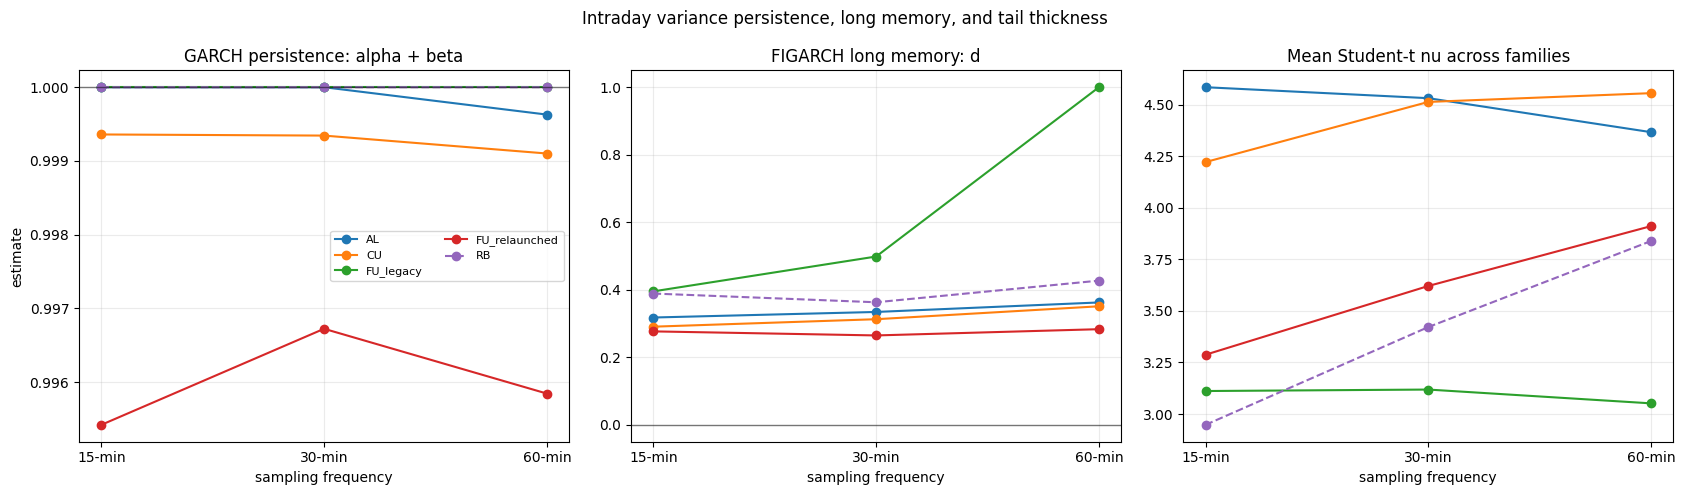

**结果摘要。** GARCH `alpha+beta` 范围为 `0.9954`—`1.0000`。FIGARCH `d` 范围为 `0.2648`—`1.0000`，其中 `7/15` 在稳健 1% 双侧口径下显著为正。Student-t `nu` 范围为 `2.916`—`4.933`。45 个模型中 `39` 个通过稳健协方差数值门禁；`20/45` 个 MA 系数在 5% 水平显著为负。RB 只与自身三个频率比较，不被并入论文品种结论。

In [13]:
display(
    persistence_df.sort_values(
        ["model_family", "series_id", "interval_label"]
    ).reset_index(drop=True).round(6)
)

figure, axes = plt.subplots(1, 3, figsize=(17, 5))
frequency_positions = np.arange(len(interval_order))
series_color_map = dict(zip(series_order, plt.cm.tab10.colors[: len(series_order)]))

for series_id in series_order:
    line_style = "--" if series_id == "RB" else "-"
    garch_rows = persistence_df.loc[
        (persistence_df["series_id"] == series_id)
        & (persistence_df["model_family"] == "GARCH")
    ].set_index("interval_label").reindex(interval_order)
    axes[0].plot(
        frequency_positions,
        garch_rows["garch_persistence"],
        marker="o",
        linestyle=line_style,
        color=series_color_map[series_id],
        label=series_id,
    )

    figarch_rows = persistence_df.loc[
        (persistence_df["series_id"] == series_id)
        & (persistence_df["model_family"] == "FIGARCH")
    ].set_index("interval_label").reindex(interval_order)
    axes[1].plot(
        frequency_positions,
        figarch_rows["figarch_d"],
        marker="o",
        linestyle=line_style,
        color=series_color_map[series_id],
        label=series_id,
    )

    nu_rows = (
        persistence_df.loc[persistence_df["series_id"] == series_id]
        .groupby("interval_label", observed=True)["student_nu"]
        .mean()
        .reindex(interval_order)
    )
    axes[2].plot(
        frequency_positions,
        nu_rows,
        marker="o",
        linestyle=line_style,
        color=series_color_map[series_id],
        label=series_id,
    )

axes[0].axhline(1.0, color="black", linewidth=1, alpha=0.5)
axes[0].set_title("GARCH persistence: alpha + beta")
axes[1].axhline(0.0, color="black", linewidth=1, alpha=0.5)
axes[1].set_title("FIGARCH long memory: d")
axes[2].set_title("Mean Student-t nu across families")
for axis in axes:
    axis.set_xticks(frequency_positions, interval_order)
    axis.grid(alpha=0.25)
    axis.set_xlabel("sampling frequency")
axes[0].set_ylabel("estimate")
axes[0].legend(ncol=2, fontsize=8)
figure.suptitle("Intraday variance persistence, long memory, and tail thickness")
figure.tight_layout()
plt.show()

garch_persistence_rows = persistence_df.loc[
    persistence_df["model_family"] == "GARCH"
]
figarch_parameter_rows = parameter_result_df.loc[
    (parameter_result_df["model_family"] == "FIGARCH")
    & (parameter_result_df["parameter"] == "d")
]
negative_ma_rows = parameter_result_df.loc[
    (parameter_result_df["parameter"] == "theta")
    & parameter_result_df["free_parameter"]
]
valid_covariance_model_count = int(
    fit_summary_df["covariance_status"].eq("valid").sum()
)
significant_positive_d_count = int(
    (
        figarch_parameter_rows["estimate"].gt(0)
        & figarch_parameter_rows["p_value"].lt(0.01)
    ).sum()
)
significant_negative_theta_count = int(
    (
        negative_ma_rows["estimate"].lt(0)
        & negative_ma_rows["p_value"].lt(0.05)
    ).sum()
)

display(
    Markdown(
        f"**结果摘要。** GARCH `alpha+beta` 范围为 "
        f"`{garch_persistence_rows['garch_persistence'].min():.4f}`—"
        f"`{garch_persistence_rows['garch_persistence'].max():.4f}`。"
        f"FIGARCH `d` 范围为 `{figarch_parameter_rows['estimate'].min():.4f}`—"
        f"`{figarch_parameter_rows['estimate'].max():.4f}`，其中 "
        f"`{significant_positive_d_count}/15` 在稳健 1% 双侧口径下显著为正。"
        f"Student-t `nu` 范围为 `{fit_summary_df['nu'].min():.3f}`—"
        f"`{fit_summary_df['nu'].max():.3f}`。45 个模型中 "
        f"`{valid_covariance_model_count}` 个通过稳健协方差数值门禁；"
        f"`{significant_negative_theta_count}/45` 个 MA 系数在 5% 水平显著为负。"
        "RB 只与自身三个频率比较，不被并入论文品种结论。"
    )
)

## 12. 独立公式复核与验证门禁

独立验证不只检查优化器状态：还用显式 Python 循环复核代表模型的 ARMA 递推，并用标准化 Student-t 的打印公式手工重算完整对数似然。稳健协方差是常规渐近近似；边界模型或 Hessian 数值失败不会用伪逆静默制造 t 值。

In [14]:
assert representative_fit_context is not None
representative_returns = representative_fit_context["observed_return_values"]
representative_bundle = representative_fit_context["fit_bundle"]
representative_parameters = representative_bundle["parameters"]

representative_base = (
    representative_returns[1:]
    - representative_parameters[0]
    - representative_parameters[1] * representative_returns[:-1]
)
manual_representative_innovations = np.empty_like(representative_base)
manual_representative_innovations[0] = representative_base[0]
for innovation_index in range(1, len(manual_representative_innovations)):
    manual_representative_innovations[innovation_index] = (
        representative_base[innovation_index]
        - representative_parameters[2]
        * manual_representative_innovations[innovation_index - 1]
    )
representative_innovation_maximum_error = float(
    np.max(
        np.abs(
            manual_representative_innovations
            - representative_bundle["innovations"]
        )
    )
)

representative_nu = representative_parameters[-1]
representative_innovations = representative_bundle["innovations"]
representative_variance = representative_bundle["conditional_variance"]
manual_loglikelihood_terms = (
    gammaln((representative_nu + 1.0) / 2.0)
    - gammaln(representative_nu / 2.0)
    - 0.5 * np.log(np.pi * (representative_nu - 2.0))
    - 0.5 * np.log(representative_variance)
    - ((representative_nu + 1.0) / 2.0)
    * np.log1p(
        np.square(representative_innovations)
        / (representative_variance * (representative_nu - 2.0))
    )
)
manual_representative_loglikelihood = float(np.sum(manual_loglikelihood_terms))
optimized_representative_loglikelihood = -float(
    representative_bundle["optimization_result"].fun
)
representative_loglikelihood_error = abs(
    manual_representative_loglikelihood
    - optimized_representative_loglikelihood
)

expected_factor_count = len(series_order) * int(
    interval_spec_df["expected_daily_slots"].sum()
)
expected_model_count = (
    len(series_order) * len(interval_order) * len(model_family_order)
)
model_parameter_constraint_pass = (
    fit_summary_df["gamma"].abs().le(arma_absolute_bound + 1e-8).all()
    and fit_summary_df["theta"].abs().le(arma_absolute_bound + 1e-8).all()
    and fit_summary_df["omega"].ge(-1e-8).all()
    and fit_summary_df["nu"].gt(2).all()
)
garch_rows = fit_summary_df.loc[fit_summary_df["model_family"] == "GARCH"]
igarch_rows = fit_summary_df.loc[fit_summary_df["model_family"] == "IGARCH"]
figarch_rows = fit_summary_df.loc[fit_summary_df["model_family"] == "FIGARCH"]
garch_constraint_pass = (
    garch_rows["alpha"].ge(-1e-8).all()
    and garch_rows["beta"].ge(-1e-8).all()
    and garch_rows["garch_persistence"].le(garch_persistence_cap + 1e-7).all()
)
igarch_constraint_pass = (
    igarch_rows["alpha"].between(-1e-8, 1.0 + 1e-8).all()
    and np.allclose(
        igarch_rows["alpha"] + igarch_rows["beta"],
        1.0,
        atol=1e-12,
        rtol=0.0,
    )
)
figarch_constraint_pass = (
    figarch_rows["d"].between(-1e-8, 1.0 + 1e-8).all()
    and figarch_rows["phi"].ge(-1e-8).all()
    and (2 * figarch_rows["phi"] + figarch_rows["d"]).le(1.0 + 1e-7).all()
    and figarch_rows["beta"].ge(-1e-8).all()
    and figarch_rows["beta"].le(
        figarch_rows["d"] + figarch_rows["phi"] + 1e-7
    ).all()
)

convergence_failure_df = fit_summary_df.loc[
    (~fit_summary_df["success"])
    | (~fit_summary_df["is_feasible"])
    | fit_summary_df["minimum_constraint_slack"].lt(
        -optimization_feasibility_tolerance
    ),
    [
        "series_id",
        "interval_label",
        "model_family",
        "success",
        "status",
        "message",
        "minimum_constraint_slack",
        "minimum_bound_slack",
        "alpha",
        "beta",
        "phi",
        "d",
        "garch_persistence",
    ],
]
constraint_detail_df = fit_summary_df[
    [
        "series_id",
        "interval_label",
        "model_family",
        "omega",
        "alpha",
        "beta",
        "phi",
        "d",
        "nu",
        "garch_persistence",
        "minimum_constraint_slack",
        "minimum_bound_slack",
    ]
].copy()
if not convergence_failure_df.empty or not (
    model_parameter_constraint_pass
    and garch_constraint_pass
    and igarch_constraint_pass
    and figarch_constraint_pass
):
    display(Markdown("### 未通过门禁的模型诊断"))
    display(convergence_failure_df)
    display(constraint_detail_df)

fu_legacy_last_date = model_return_df.loc[
    model_return_df["series_id"] == "FU_legacy", "trading_date"
].max()
fu_relaunched_first_date = model_return_df.loc[
    model_return_df["series_id"] == "FU_relaunched", "trading_date"
].min()

validation_gate_df = pd.DataFrame(
    [
        ("latitude_environment", current_python == expected_python, str(current_python)),
        (
            "source_schema_physical_compatibility",
            source_contract_audit_df["physical_mismatch_count"].eq(0).all(),
            ", ".join(source_contract_audit_df["table_name"]),
        ),
        (
            "unique_trade_month_plus_three_contract",
            contract_mapping_audit_df["target_contract_count"].isin([0, 1]).all()
            and contract_series_df["contract_code"].eq(
                contract_series_df["expected_contract_code"]
            ).all()
            and actual_missing_keys_df.equals(known_missing_keys_df),
            "唯一固定三个月合约；仅排除 22 日 FU1102.XSGE 未上市缺口",
        ),
        (
            "day_sessions_and_minute_alignment",
            not contract_calendar_df["is_night_session"].any()
            and not bar_calendar_df["is_night_session"].any()
            and complete_contract_day_df["is_complete_contract_day"].all()
            and minute_read_audit_df["session_alignment_failures"].eq(0).all(),
            f"{len(complete_contract_day_df):,} 合约日；{int(minute_read_audit_df['selected_day_minute_rows'].sum()):,} 日盘分钟",
        ),
        (
            "intraday_slot_structure",
            slot_audit_df[
                [
                    "slot_count_failures",
                    "aggregated_minute_count_failures",
                    "non_last_slot_length_failures",
                    "last_slot_length_failures",
                ]
            ].eq(0).all().all(),
            "每日 15/8/4 槽；30/60 分钟末槽 15/45 分钟",
        ),
        (
            "full_sample_seasonality_factors",
            len(seasonality_factor_df) == expected_factor_count
            and np.isfinite(seasonality_factor_df["seasonality_factor"]).all()
            and seasonality_factor_df["seasonality_factor"].gt(0).all()
            and full_sample_factor_audit_df[
                "mean_squared_deseasonalized_return"
            ].sub(1.0).abs().max() < 1e-12,
            f"{len(seasonality_factor_df)} 个全文样本因子；每槽 mean(r_tilde^2)=1",
        ),
        (
            "initial_and_oos_day_counts",
            model_sample_df.set_index("series_id")["oos_days"].to_dict()
            == {"AL": 300, "CU": 300, "FU_legacy": 200, "FU_relaunched": 200, "RB": 300}
            and panel_audit_df["input_returns"].eq(
                panel_audit_df["expected_input_returns"]
            ).all(),
            "; ".join(
                f"{row.series_id}: initial={row.initial_sample_days}, OOS={row.oos_days}"
                for row in model_sample_df.itertuples(index=False)
            ),
        ),
        (
            "arma_filter_manual_recursion",
            manual_filter_maximum_error < 1e-14
            and representative_innovation_maximum_error < 1e-12,
            f"小样本误差={manual_filter_maximum_error:.3e}; AL15误差={representative_innovation_maximum_error:.3e}",
        ),
        (
            "student_t_manual_loglikelihood",
            representative_loglikelihood_error < 1e-8,
            f"AL 15-min GARCH 手工对数似然误差={representative_loglikelihood_error:.3e}",
        ),
        (
            "complete_model_grid_and_convergence",
            len(fit_summary_df) == expected_model_count
            and fit_summary_df["success"].all()
            and fit_summary_df["is_feasible"].all()
            and fit_summary_df["minimum_constraint_slack"].ge(
                -optimization_feasibility_tolerance
            ).all(),
            f"{len(fit_summary_df)}/45 模型；全部选择成功且可行的起点",
        ),
        (
            "conditional_variances_finite_positive",
            fit_summary_df["minimum_conditional_variance"].gt(0).all()
            and np.isfinite(
                fit_summary_df[
                    [
                        "minimum_conditional_variance",
                        "maximum_conditional_variance",
                        "loglikelihood",
                    ]
                ].to_numpy()
            ).all(),
            "45 个模型的条件方差有限且严格为正",
        ),
        (
            "model_parameter_constraints",
            model_parameter_constraint_pass
            and garch_constraint_pass
            and igarch_constraint_pass
            and figarch_constraint_pass,
            "ARMA 边界、GARCH 严格持久性帽、IGARCH 等式与 FIGARCH 可行域均通过",
        ),
        (
            "standardized_student_t_only",
            fit_summary_df["nu"].gt(2).all()
            and len(parameter_result_df.loc[parameter_result_df["parameter"] == "nu"]) == expected_model_count,
            "45 个模型均估计 nu；未切换正态",
        ),
        (
            "figarch_truncation_1000",
            all(
                fit_bundle_by_key[(series_id, interval_label, "FIGARCH")][
                    "volatility_process"
                ].truncation == figarch_truncation
                for series_id in series_order
                for interval_label in interval_order
            ),
            f"15 个 FIGARCH 均为 truncation={figarch_truncation}",
        ),
        (
            "covariance_diagnostics_explicit",
            fit_summary_df["covariance_status"].notna().all()
            and parameter_result_df["covariance_status"].notna().all(),
            f"有效稳健协方差 {valid_covariance_model_count}/45；其余显式标记，不使用伪逆",
        ),
        (
            "fu_segments_are_independent",
            fu_legacy_last_date < fu_relaunched_first_date
            and ("FU_legacy", "15-min", "GARCH") in fit_bundle_by_key
            and ("FU_relaunched", "15-min", "GARCH") in fit_bundle_by_key,
            f"legacy_end={fu_legacy_last_date.date()}, relaunched_start={fu_relaunched_first_date.date()}",
        ),
        (
            "rb_extension_is_separate",
            sample_spec_df.loc[
                sample_spec_df["series_id"] == "RB", "research_role"
            ].eq("论文外扩展品种").all()
            and all(("RB", interval_label, model_family) in fit_bundle_by_key for interval_label in interval_order for model_family in model_family_order),
            "RB 9 个模型独立列示",
        ),
    ],
    columns=["gate", "passed", "evidence"],
)

display(validation_gate_df)
assert validation_gate_df["passed"].all(), validation_gate_df.loc[
    ~validation_gate_df["passed"]
]

,gate,passed,evidence
0,latitude_environment,True,E:\anaconda3\envs\latitude\python.exe
1,source_schema_physical_compatibility,True,"dim_futures_variety_calendar, dim_futures_contract_calendar, dim_futures_bar_calendar, fact_futures_minute"
2,unique_trade_month_plus_three_contract,True,唯一固定三个月合约；仅排除 22 日 FU1102.XSGE 未上市缺口
3,day_sessions_and_minute_alignment,True,"14,153 合约日；3,184,425 日盘分钟"
4,intraday_slot_structure,True,每日 15/8/4 槽；30/60 分钟末槽 15/45 分钟
5,full_sample_seasonality_factors,True,135 个全文样本因子；每槽 mean(r_tilde^2)=1
6,initial_and_oos_day_counts,True,"AL: initial=3745, OOS=300; CU: initial=3745, OOS=300; FU_legacy: initial=204, OOS=200; FU_relaunched: initial=1414, OOS=200; RB: initial=3745, OOS=300"
7,arma_filter_manual_recursion,True,小样本误差=0.000e+00; AL15误差=0.000e+00
8,student_t_manual_loglikelihood,True,AL 15-min GARCH 手工对数似然误差=0.000e+00
9,complete_model_grid_and_convergence,True,45/45 模型；全部选择成功且可行的起点


## 13. 结果解释与限制

解释顺序应保持克制：

1. `α+β` 接近 1 表示波动冲击消退很慢，但只有 IGARCH 才把其精确固定为 1；
2. FIGARCH 的 `d>0` 支持长记忆，是否“显著”只在稳健协方差通过数值门禁时判断；
3. 低 `ν` 表示即使在条件方差建模后，标准化创新仍厚尾；
4. 负 `θ` 可与高频反转和微观结构噪声一致，但不能单凭该系数识别具体机制；
5. RB 是外部扩展，只能用于方法稳健性比较，不能倒写成论文原结论。

限制与后续边界：

- 使用 JQData 2010 年以后日盘事实，不是论文 GTA 样本；项目每日 225 分钟，论文原样本每日 240 分钟；
- 全文样本周期因子含前视，本项只复现论文基线。实时无前视预测将在第 09 项按预测原点重算；
- 日界、换月与 FU_legacy 的 2010-11 缺口处继续条件状态，是论文未披露后的项目选择；价格收益本身仍不含这些跳空；
- 回溯方差、variance bounds、SLSQP 容差、三个 MA 起点、GARCH 数值严格帽、Student-t 数值边界和稳健协方差均是明确记录的实现选择；
- 普通 Wald t 值在参数边界附近不具有标准渐近分布。Notebook 报告 `boundary_flag`、Hessian 诊断，并在数值门禁失败时保留 NA；
- 本项只做静态初始样本估计。第 09 项的每日滚动、多步条件均值/方差预测与重新季节化必须在对应 Notebook 自行重算，不能直接读取本 Notebook 的内存对象。